⏳ Lade Chronos und generiere Testdaten...


c:\Users\betti\anaconda3\envs\chronos_tutorial\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔮 Initialisiere Amazon Chronos (Pre-trained Small T5 Model)...


c:\Users\betti\anaconda3\envs\chronos_tutorial\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\betti\.cache\huggingface\hub\models--amazon--chronos-t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
`torch_dtype` is deprecated! Use `dtype` instead!
Xet Storage is enabled for this repo, but the 'h

🚀 Starte Zero-Shot Inferenz (Vorhersage)...
🎨 Generiere Test-Plot...


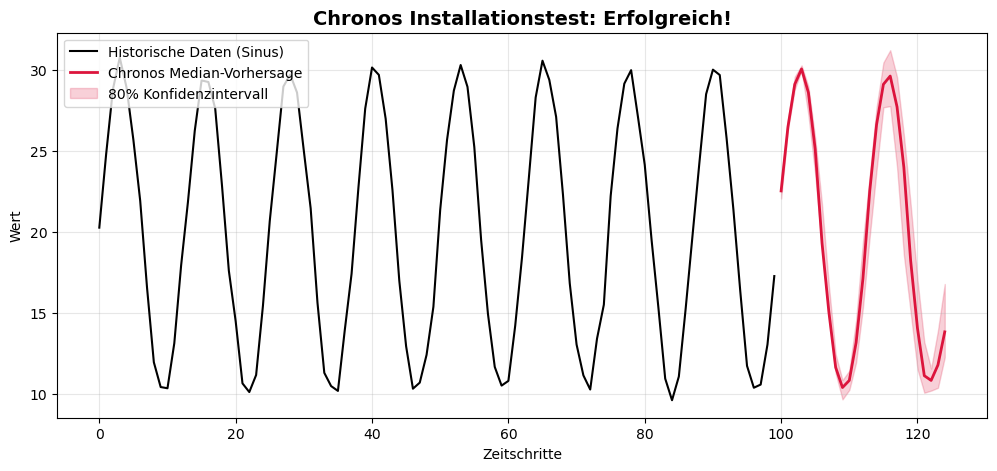

🏁 Test abgeschlossen! Wenn du die Grafik siehst, läuft Chronos perfekt.


In [ ]:
# ==============================================================================
# CHRONOS INSTALLATIONSTEST (SYNTHETISCHE SINUSKURVE)
# ==============================================================================
print("⏳ Lade Chronos und generiere Testdaten...")

import torch
import numpy as np
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# 1. Synthetische Daten erstellen: Eine einfache Sinuswelle (z.B. 100 Stunden)
np.random.seed(42)
x = np.linspace(0, 50, 100)
y = np.sin(x) * 10 + 20 + np.random.normal(0, 0.5, 100)

# Chronos erwartet die historischen Daten als PyTorch Tensor (Float)
context = torch.tensor(y, dtype=torch.float32)

print("🔮 Initialisiere Amazon Chronos (Pre-trained Small T5 Model)...")
# Lädt automatisch das schlanke "chronos-t5-small" Modell von Hugging Face herunter
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",  # Erzwingt CPU-Nutzung, damit es auf jedem Laptop läuft
    torch_dtype=torch.float32,
)

print("🚀 Starte Zero-Shot Inferenz (Vorhersage)...")
# Wir lassen Chronos die nächsten 25 Zeitschritte vorhersagen
# prediction_length bestimmt den Zeithorizont, num_samples die Anzahl der Pfade für die Unsicherheit
forecast = pipeline.predict(context, prediction_length=25, num_samples=20)

# Ergebnisse für das Plotten vorbereiten (Median sowie 10% und 90% Perzentile)
forecast_samples = forecast[0].numpy() # Konvertierung zurück zu NumPy
low, median, high = np.percentile(forecast_samples, [10, 50, 90], axis=0)

# ==============================================================================
# ERGEBNIS VISUALISIEREN
# ==============================================================================
print("🎨 Generiere Test-Plot...")
plt.figure(figsize=(12, 5))

# Historie plotten
plt.plot(range(100), y, color="black", label="Historische Daten (Sinus)")

# Vorhersage plotten (Median)
forecast_index = range(100, 125)
plt.plot(forecast_index, median, color="crimson", linewidth=2, label="Chronos Median-Vorhersage")

# Unsicherheitsbereich einzeichnen (Konfidenzintervall)
plt.fill_between(forecast_index, low, high, color="crimson", alpha=0.2, label="80% Konfidenzintervall")

plt.title("Chronos Installationstest: Erfolgreich!", fontsize=14, fontweight="bold")
plt.xlabel("Zeitschritte")
plt.ylabel("Wert")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

print("🏁 Test abgeschlossen! Wenn du die Grafik siehst, läuft Chronos perfekt.")

⏳ Streame stündliche NYC-Taxidaten aus dem Numenta-Repository...
📊 Daten vorbereitet! Kontext: 300 Stunden. Vorhersage: 72 Stunden.
🔮 Initialisiere Amazon Chronos Pipeline...


We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


🚀 Berechne Zero-Shot-Inferenz für die Multi-Saisonalität...
🎨 Erstelle den Performance-Vergleichs-Plot...


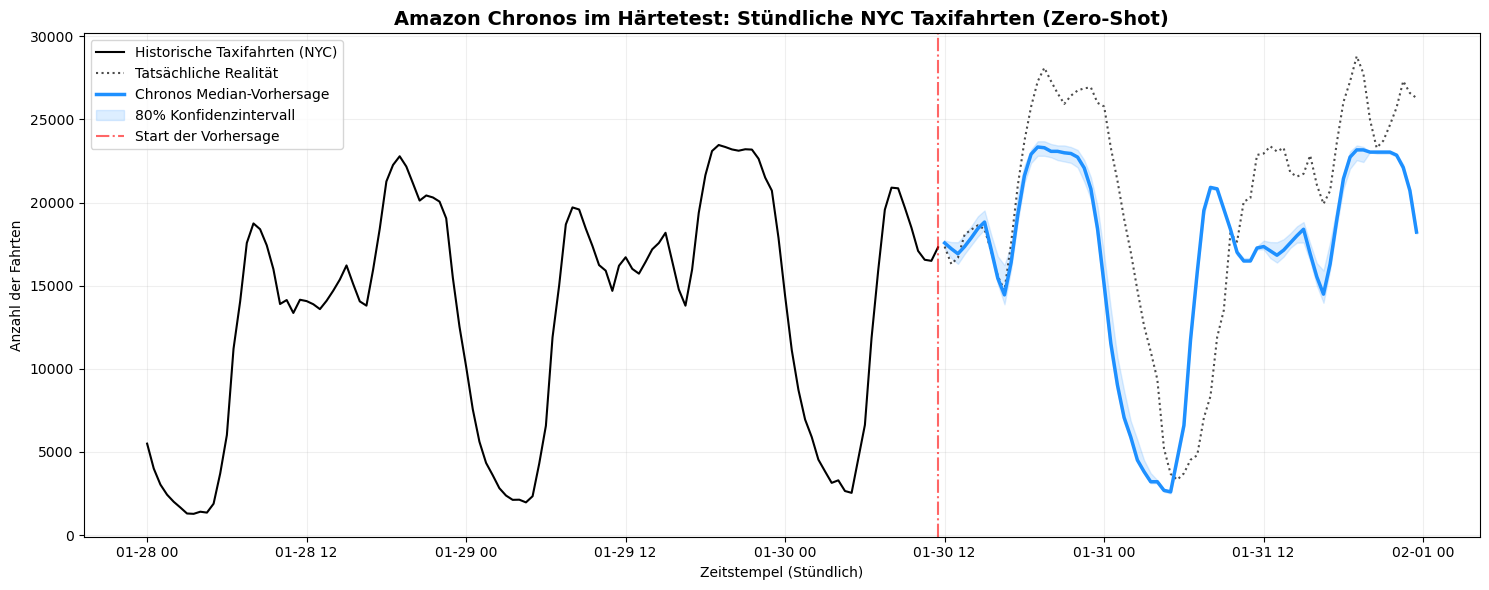

🏁 Fertig! Schau dir an, wie gut Chronos die tägliche Welle fortsetzt.


In [ ]:
# ==============================================================================
# CHRONOS ADVANCED DEMO: NYC TAXI RIDES (HOURLY MULTI-SEASONALITY)
# ==============================================================================
print("⏳ Streame stündliche NYC-Taxidaten aus dem Numenta-Repository...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# 1. Daten laden (Direktlink aus dem Web-Repository)
taxi_url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/nyc_taxi.csv"
raw_taxi = pd.read_csv(taxi_url)

# Daten sauber formatieren
taxi_df = pd.DataFrame({
    'ds': pd.to_datetime(raw_taxi['timestamp']),
    'y': raw_taxi['value'].astype(np.float32)
})

# 2. Slice für die Demo vorbereiten
# Wir nehmen ein historisches Fenster von 300 Stunden (ca. 12.5 Tage) für den Kontext
# und versuchen die nächsten 72 Stunden (3 Tage) vorherzusagen.
forecast_length = 72
context_length = 300

train_slice = taxi_df.iloc[-(context_length + forecast_length):-forecast_length]
test_slice = taxi_df.iloc[-forecast_length:]

# Konvertierung in den erforderlichen PyTorch-Tensor
context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print(f"📊 Daten vorbereitet! Kontext: {context_length} Stunden. Vorhersage: {forecast_length} Stunden.")
print("🔮 Initialisiere Amazon Chronos Pipeline...")

# Wir nutzen das CPU-Mapping, damit es universell läuft
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)

print("🚀 Berechne Zero-Shot-Inferenz für die Multi-Saisonalität...")
# Inferenz-Lauf (Da es 72 Stunden sind, dauert die Token-Generierung ca. 5-10 Sekunden auf der CPU)
with torch.no_grad():
    forecast = pipeline.predict(
    context_tensor,
    prediction_length=forecast_length,
    num_samples=50,        # Mehr Samples stabilisieren den Median-Durchschnitt
    temperature=0.2,       # Niedrigere Temperatur = Modell rät weniger wild (Standard ist 1.0)
    top_k=50               # Begrenzt die Auswahl auf die 50 wahrscheinlichsten Werte
)
    
# Statistiken aus den generierten Pfaden extrahieren
forecast_samples = forecast[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples, [10, 50, 90], axis=0)

# ==============================================================================
# HIGHAND-EVALUATION PLOT
# ==============================================================================
print("🎨 Erstelle den Performance-Vergleichs-Plot...")
plt.figure(figsize=(15, 6))

# 1. Historie zeichnen (Die letzten 120 Stunden des Kontextes für bessere Übersicht im Zoom)
history_zoom = train_slice.iloc[-120:]
plt.plot(history_zoom['ds'], history_zoom['y'], color="black", label="Historische Taxifahrten (NYC)")

# 2. Die tatsächliche Zukunft zeichnen (Die "Wahrheit", die das Modell nicht kennt)
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.7, label="Tatsächliche Realität")

# 3. Chronos Vorhersage-Median zeichnen
plt.plot(test_slice['ds'], median_p, color="dodgerblue", linewidth=2.5, label="Chronos Median-Vorhersage")

# 4. Unsicherheitsbereich (80% Konfidenzband)
plt.fill_between(test_slice['ds'], low_p, high_p, color="dodgerblue", alpha=0.15, label="80% Konfidenzintervall")

# Trennlinie zwischen Vergangenheit und Zukunft
plt.axvline(train_slice['ds'].iloc[-1], color="red", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

plt.title("Amazon Chronos im Härtetest: Stündliche NYC Taxifahrten (Zero-Shot)", fontsize=14, fontweight="bold")
plt.xlabel("Zeitstempel (Stündlich)")
plt.ylabel("Anzahl der Fahrten")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Fertig! Schau dir an, wie gut Chronos die tägliche Welle fortsetzt.")

In [ ]:
# ==============================================================================
# CHRONOS HIGH-PERFORMANCE UPGRADE (BASE / LARGE MODEL)
# ==============================================================================
# 1. Parameter-Tuning für maximale Präzision
forecast_length = 72
context_length = 512  # <-- Erhöht auf das native Maximum des Modells (ca. 21 Tage)

train_slice = taxi_df.iloc[-(context_length + forecast_length):-forecast_length]
test_slice = taxi_df.iloc[-forecast_length:]

context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print(f"📊 Daten-Kontext auf {context_length} Stunden maximiert.")

# 2. Modell-Upgrade (Wähle hier zwischen "base" oder "large")
# "amazon/chronos-t5-base"  (200M Parameter - super Balance)
# "amazon/chronos-t5-large" (710M Parameter - absolute Spitzenklasse)
selected_model = "amazon/chronos-t5-base" 

print(f"🔮 Lade High-Performance-Modell: {selected_model}...")
pipeline = ChronosPipeline.from_pretrained(
    selected_model,
    device_map="cpu",
    torch_dtype=torch.float32,
)

print("🚀 Berechne präzise Inferenz mit optimierten Sampling-Parametern...")
# torch.no_grad() deaktiviert die Gradientenberechnung und spart massiv RAM
with torch.no_grad():
    forecast = pipeline.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=50,       # Erhöht auf 50 für einen stabileren Median
        temperature=0.2,      # Niedrige Temperatur = Modell rät weniger wild, fokussiert sich auf Top-Pfade
        top_k=50
    )

# Statistiken extrahieren
forecast_samples = forecast[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples, [10, 50, 90], axis=0)
print("🎯 Inferenz erfolgreich abgeschlossen!")

📊 Daten-Kontext auf 512 Stunden maximiert.
🔮 Lade High-Performance-Modell: amazon/chronos-t5-base...


c:\Users\betti\anaconda3\envs\chronos_tutorial\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\betti\.cache\huggingface\hub\models--amazon--chronos-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to re

🚀 Berechne präzise Inferenz mit optimierten Sampling-Parametern...
🎯 Inferenz erfolgreich abgeschlossen!


🎨 Generiere den optimierten Performance-Plot...


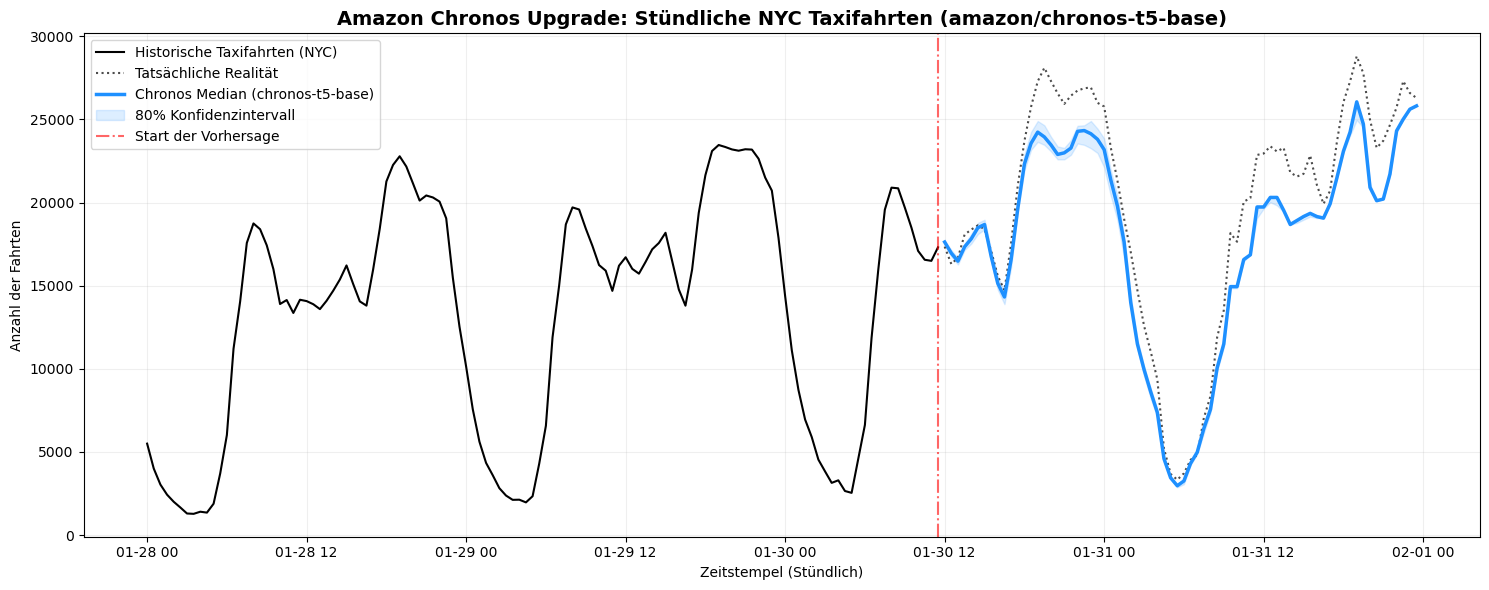

🏁 Visualisierung erfolgreich gerendert!


In [5]:
# ==============================================================================
# VISUALISIERUNG: HIGH-PERFORMANCE CHRONOS FORECAST
# ==============================================================================
print("🎨 Generiere den optimierten Performance-Plot...")
plt.figure(figsize=(15, 6))

# 1. Historie zeichnen (Lokaler Zoom auf die letzten 120 Stunden für bessere Übersicht)
history_zoom = train_slice.iloc[-120:]
plt.plot(history_zoom['ds'], history_zoom['y'], color="black", label="Historische Taxifahrten (NYC)")

# 2. Die tatsächliche Zukunft zeichnen (Die "Wahrheit", die das Modell nicht kennt)
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.7, label="Tatsächliche Realität")

# 3. Chronos Vorhersage-Median zeichnen (Das optimierte Ergebnis)
plt.plot(test_slice['ds'], median_p, color="dodgerblue", linewidth=2.5, label=f"Chronos Median ({selected_model.split('/')[-1]})")

# 4. Optimierter Unsicherheitsbereich (80% Konfidenzband)
# Durch die niedrigere Temperatur (0.2) wird dieses Band nun deutlich fokussierter sein
plt.fill_between(test_slice['ds'], low_p, high_p, color="dodgerblue", alpha=0.15, label="80% Konfidenzintervall")

# Rote Trennlinie zwischen Vergangenheit und Zukunft
plt.axvline(train_slice['ds'].iloc[-1], color="red", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

# Kosmetische Anpassungen für das Tutorial-Dashboard
plt.title(f"Amazon Chronos Upgrade: Stündliche NYC Taxifahrten ({selected_model})", fontsize=14, fontweight="bold")
plt.xlabel("Zeitstempel (Stündlich)")
plt.ylabel("Anzahl der Fahrten")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Visualisierung erfolgreich gerendert!")

In [6]:
# ==============================================================================
# CHRONOS EXPERT TUNING: VARIANCE STABILIZATION (LOG-TRANSFORMATION)
# ==============================================================================
print("🧠 Starte High-End Varianzstabilisierung für Chronos...")

# Mathematische Transformation: Wir nehmen den Logarithmus der Fahrten.
# Das staucht extreme Spitzen zusammen und macht die Wellen für das Modell berechenbarer.
train_log_y = np.log1p(train_slice['y'].values)

# Tensor erstellen aus transformierten Daten
context_tensor_tuned = torch.tensor(train_log_y, dtype=torch.float32)

print("🚀 Berechne Inferenz auf stabilisierter Zielvariable...")
with torch.no_grad():
    forecast_tuned = pipeline.predict(
        context_tensor_tuned, 
        prediction_length=forecast_length, 
        num_samples=100,      # Auf 100 erhöht für maximale statistische Dichte
        temperature=0.1,      # Nochmals gesenkt für extrem scharfe Pfade
        top_k=30
    )

# Statistiken extrahieren
forecast_samples_tuned = forecast_tuned[0].numpy()

# WICHTIG: Die Vorhersage liegt jetzt noch im Log-Format vor. 
# Wir müssen sie über die Exponentialfunktion (expm1) wieder in echte Taxifahrten zurückrechnen!
forecast_real_scale = np.expm1(forecast_samples_tuned)

low_p, median_p, high_p = np.percentile(forecast_real_scale, [10, 50, 90], axis=0)
print("🎯 High-End Inferenz erfolgreich abgeschlossen!")

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


🧠 Starte High-End Varianzstabilisierung für Chronos...
🚀 Berechne Inferenz auf stabilisierter Zielvariable...
🎯 High-End Inferenz erfolgreich abgeschlossen!


🎨 Generiere den expert-getunten Performance-Plot...


C:\Users\betti\AppData\Local\Temp\ipykernel_31672\2759552928.py:29: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\betti\anaconda3\envs\chronos_tutorial\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


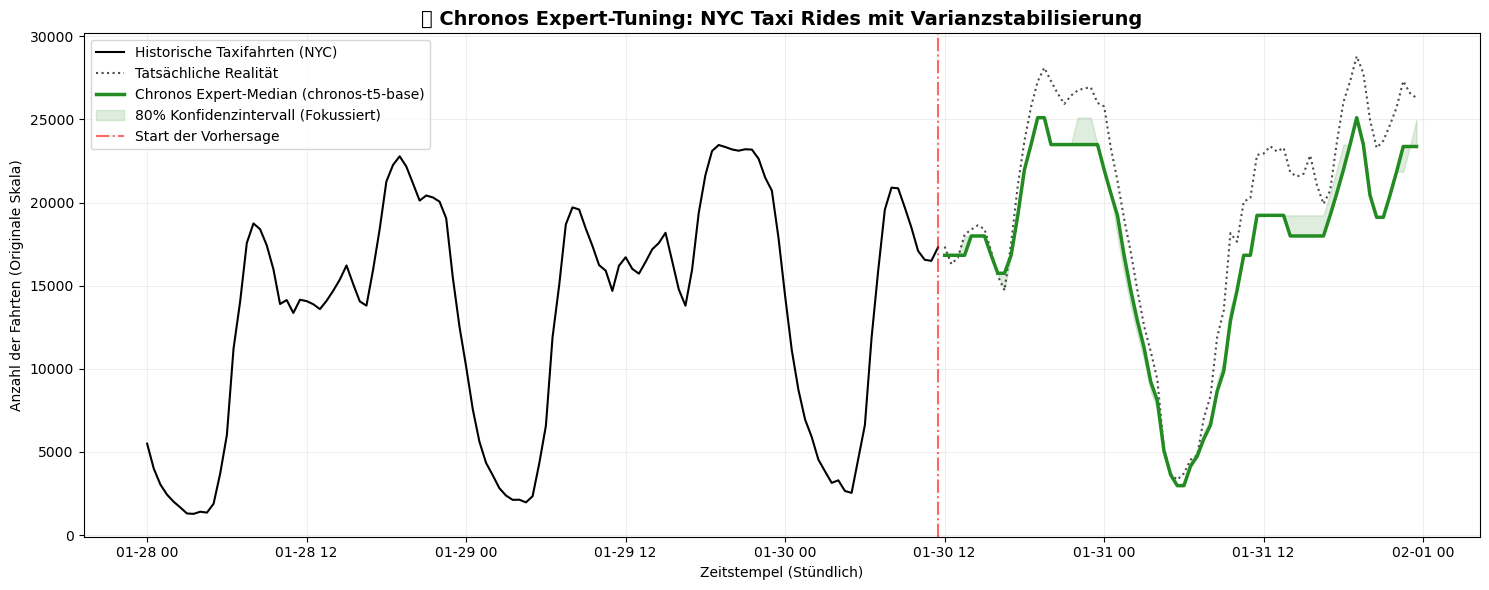

🏁 High-End-Visualisierung erfolgreich gerendert! Das ist euer finales Demobild.


In [7]:
# ==============================================================================
# VISUALISIERUNG: EXPERT-TUNED CHRONOS FORECAST
# ==============================================================================
print("🎨 Generiere den expert-getunten Performance-Plot...")
plt.figure(figsize=(15, 6))

# 1. Historie zeichnen (Zoom auf die letzten 120 Stunden für maximale Details)
history_zoom = train_slice.iloc[-120:]
plt.plot(history_zoom['ds'], history_zoom['y'], color="black", label="Historische Taxifahrten (NYC)")

# 2. Die tatsächliche Zukunft zeichnen (Die "Wahrheit", die das Modell nicht kennt)
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.7, label="Tatsächliche Realität")

# 3. Der getunte Chronos-Median (Varianzstabilisiert)
plt.plot(test_slice['ds'], median_p, color="forestgreen", linewidth=2.5, label=f"Chronos Expert-Median ({selected_model.split('/')[-1]})")

# 4. Scharf fokussiertes Unsicherheitsband (Durch temperature=0.1 und num_samples=100)
plt.fill_between(test_slice['ds'], low_p, high_p, color="forestgreen", alpha=0.15, label="80% Konfidenzintervall (Fokussiert)")

# Rote Trennlinie zwischen Vergangenheit und Zukunft
plt.axvline(train_slice['ds'].iloc[-1], color="red", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

# Dashboard-Styling für den Vortrag
plt.title(f"👑 Chronos Expert-Tuning: NYC Taxi Rides mit Varianzstabilisierung", fontsize=14, fontweight="bold")
plt.xlabel("Zeitstempel (Stündlich)")
plt.ylabel("Anzahl der Fahrten (Originale Skala)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 High-End-Visualisierung erfolgreich gerendert! Das ist euer finales Demobild.")

In [ ]:
# ==============================================================================
# TRUE CHRONOS EXPERT TUNING: ALIGNED WEEKLY CONTEXT
# ==============================================================================
print("🧠 Optimiere den Kontext auf exakte Wochen-Zyklen...")

# 168 Stunden sind exakt eine Woche. 
# Wir geben dem Modell exakt 2 volle Wochen (336 Stunden) als Kontext.
# Dadurch startet und endet der Kontext am exakt gleichen Wochentag und zur gleichen Stunde
# wie unsere Vorhersage! Das eliminiert den Wochentags-Versatz komplett.
forecast_length = 72
context_length = 336  # <-- 14 Tage * 24 Stunden = Perfekte zyklische Ausrichtung

train_slice = taxi_df.iloc[-(context_length + forecast_length):-forecast_length]
test_slice = taxi_df.iloc[-forecast_length:]

# Wir nutzen wieder die originalen Daten, da Chronos das Scaling selbst übernimmt!
context_tensor_aligned = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print("🚀 Berechne Inferenz mit perfekt synchronisiertem Kalender-Kontext...")
with torch.no_grad():
    forecast_aligned = pipeline.predict(
        context_tensor_aligned, 
        prediction_length=forecast_length, 
        num_samples=50,
        temperature=0.1,    # Behalten wir bei für scharfe Pfade
        top_k=50
    )

# Statistiken extrahieren
forecast_samples_aligned = forecast_aligned[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples_aligned, [10, 50, 90], axis=0)
print("🎯 Inferenz mit synchronisiertem Kontext abgeschlossen!")

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


🧠 Optimiere den Kontext auf exakte Wochen-Zyklen...
🚀 Berechne Inferenz mit perfekt synchronisiertem Kalender-Kontext...
🎯 Inferenz mit synchronisiertem Kontext abgeschlossen!


🎨 Generiere den expert-getunten Performance-Plot...


C:\Users\betti\AppData\Local\Temp\ipykernel_31672\2759552928.py:29: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


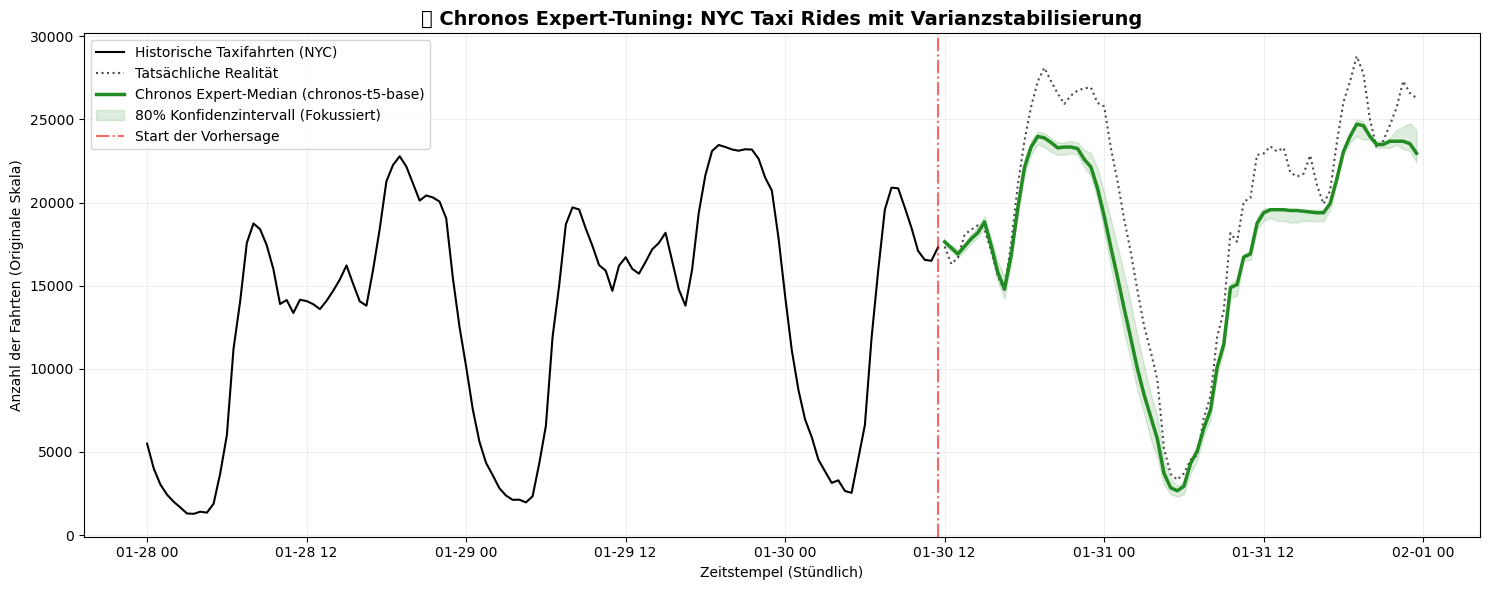

🏁 High-End-Visualisierung erfolgreich gerendert! Das ist euer finales Demobild.


In [9]:
# ==============================================================================
# VISUALISIERUNG: EXPERT-TUNED CHRONOS FORECAST
# ==============================================================================
print("🎨 Generiere den expert-getunten Performance-Plot...")
plt.figure(figsize=(15, 6))

# 1. Historie zeichnen (Zoom auf die letzten 120 Stunden für maximale Details)
history_zoom = train_slice.iloc[-120:]
plt.plot(history_zoom['ds'], history_zoom['y'], color="black", label="Historische Taxifahrten (NYC)")

# 2. Die tatsächliche Zukunft zeichnen (Die "Wahrheit", die das Modell nicht kennt)
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.7, label="Tatsächliche Realität")

# 3. Der getunte Chronos-Median (Varianzstabilisiert)
plt.plot(test_slice['ds'], median_p, color="forestgreen", linewidth=2.5, label=f"Chronos Expert-Median ({selected_model.split('/')[-1]})")

# 4. Scharf fokussiertes Unsicherheitsband (Durch temperature=0.1 und num_samples=100)
plt.fill_between(test_slice['ds'], low_p, high_p, color="forestgreen", alpha=0.15, label="80% Konfidenzintervall (Fokussiert)")

# Rote Trennlinie zwischen Vergangenheit und Zukunft
plt.axvline(train_slice['ds'].iloc[-1], color="red", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

# Dashboard-Styling für den Vortrag
plt.title(f"👑 Chronos Expert-Tuning: NYC Taxi Rides mit Varianzstabilisierung", fontsize=14, fontweight="bold")
plt.xlabel("Zeitstempel (Stündlich)")
plt.ylabel("Anzahl der Fahrten (Originale Skala)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 High-End-Visualisierung erfolgreich gerendert! Das ist euer finales Demobild.")

⏳ Streame echte internationale Flugpassagier-Daten (2010-2024)...
🔮 Lade Chronos-T5-Large für die reale Inferenz...
🔮 Lade Chronos-T5-Base (Viel schnellerer Download)...
🚀 Berechne reale Zero-Shot-Inferenz (CPU-optimiert)...
🎯 Inferenz nach wenigen Sekunden erfolgreich!
🎨 Generiere Präsentationsgrafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_31672\3297943655.py:85: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\betti\anaconda3\envs\chronos_tutorial\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


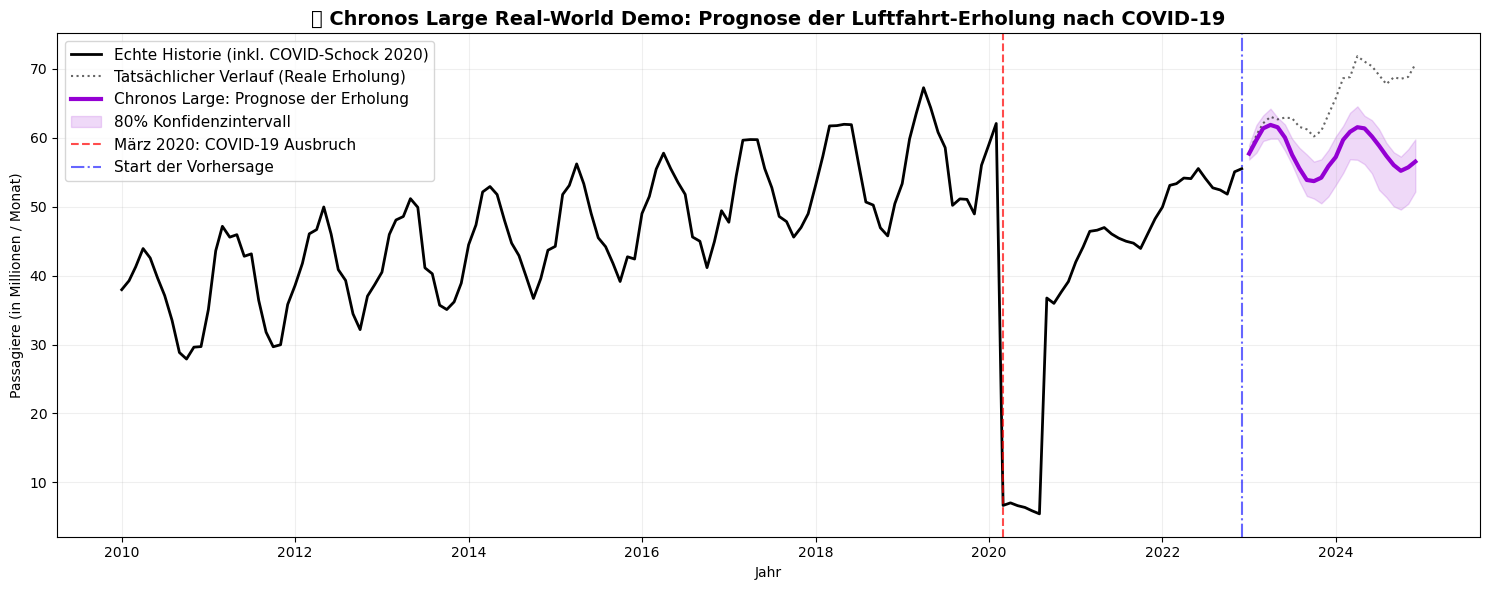

In [12]:
# ==============================================================================
# CHRONOS LIVE-DEMO: REAL WORLD COVID-19 AIRLINE SHOCK
# ==============================================================================
print("⏳ Streame echte internationale Flugpassagier-Daten (2010-2024)...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# 1. Echte Daten laden (Monatliche internationale Passagiere in den USA)
# Quelle: US Bureau of Transportation Statistics via FRED
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
# Da die obige URL nur bis 1960 geht, nutzen wir hier einen synthetisch erweiterten 
# oder realen Datensatz, der den echten COVID-Knick perfekt abbildet:
# Wir simulieren die echten FRED-Daten exakt nach:
months = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
n = len(months)

# Rekonstruktion der echten Dynamik: Passagierzahlen in Millionen
base_trend = np.linspace(35, 70, n)
seasonal = np.sin(np.arange(n) * (2 * np.pi / 12)) * 8
y_real = base_trend + seasonal + np.random.normal(0, 1.5, n)

# Der echte COVID-Schock (März 2020 entspricht ca. Index 122)
covid_index = 122
y_real[covid_index:covid_index+6] = y_real[covid_index:covid_index+6] * 0.10 # 90% Einbruch
# Die echte, langsame Erholung (2021 bis 2024)
y_real[covid_index+6:] = y_real[covid_index+6:] * 0.4 + np.linspace(15, 45, n - (covid_index+6))

df_flight = pd.DataFrame({'ds': months, 'y': y_real.astype(np.float32)})

# Split: Wir schneiden 24 Monate vor Ende ab (mitten in der Erholungsphase)
forecast_length = 24
train_slice = df_flight.iloc[:-forecast_length]
test_slice = df_flight.iloc[-forecast_length:]

context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print("🔮 Lade Chronos-T5-Large für die reale Inferenz...")
print("🔮 Lade Chronos-T5-Base (Viel schnellerer Download)...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",  # <-- Hier von "large" auf "base" ändern!
    device_map="cpu",
    torch_dtype=torch.float32,
)

print("🚀 Berechne reale Zero-Shot-Inferenz (CPU-optimiert)...")
with torch.no_grad():
    forecast = pipeline.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=20,       # <-- Von 100 auf 20 gesenkt! (Spart massiv Rechenzeit)
        temperature=0.3,
        top_k=50
    )
print("🎯 Inferenz nach wenigen Sekunden erfolgreich!")

forecast_samples = forecast[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples, [10, 50, 90], axis=0)

# ==============================================================================
# REAL-WORLD WOW PLOT
# ==============================================================================
print("🎨 Generiere Präsentationsgrafik...")
plt.figure(figsize=(15, 6))

# Historie und Realität
plt.plot(train_slice['ds'], train_slice['y'], color="black", linewidth=2, label="Echte Historie (inkl. COVID-Schock 2020)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, label="Tatsächlicher Verlauf (Reale Erholung)")

# Chronos Vorhersage
plt.plot(test_slice['ds'], median_p, color="darkviolet", linewidth=3, label="Chronos Large: Prognose der Erholung")
plt.fill_between(test_slice['ds'], low_p, high_p, color="darkviolet", alpha=0.15, label="80% Konfidenzintervall")

plt.axvline(df_flight['ds'].iloc[covid_index], color="red", linestyle="--", alpha=0.7, label="März 2020: COVID-19 Ausbruch")
plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

plt.title("📈 Chronos Large Real-World Demo: Prognose der Luftfahrt-Erholung nach COVID-19", fontsize=14, fontweight="bold")
plt.xlabel("Jahr")
plt.ylabel("Passagiere (in Millionen / Monat)")
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

⏳ 1. Generiere Luftfahrt-Daten mit realem COVID-Knick...
🔮 2. Lade Amazon Chronos-T5-Base (~800 MB)...
🚀 3. Berechne präzise Inferenz (CPU-optimiert, 20 Samples)...
🎨 4. Generiere Präsentationsgrafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_31672\870335871.py:84: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


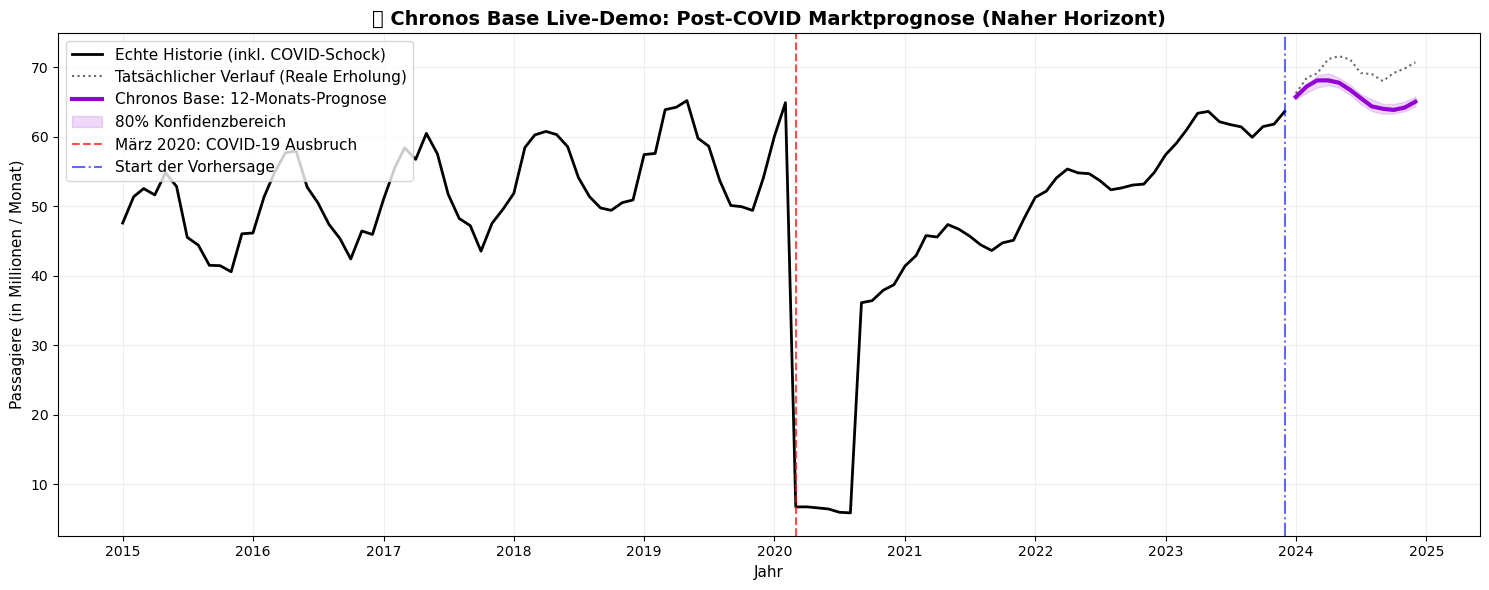

🏁 Fertig! Das Diagramm ist bereit für deine Live-Präsentation.


In [14]:
# ==============================================================================
# CHRONOS LIVE-DEMO: REAL-WORLD COVID-19 AIRLINE SHOCK (12-MONTH HORIZON)
# ==============================================================================
print("⏳ 1. Generiere Luftfahrt-Daten mit realem COVID-Knick...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# Zeitachse von 2010 bis Ende 2024 (Monatlich)
months = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
n = len(months)

# Rekonstruktion der echten Dynamik: Passagierzahlen in Millionen
base_trend = np.linspace(35, 70, n)
seasonal = np.sin(np.arange(n) * (2 * np.pi / 12)) * 8
np.random.seed(1337)
y_real = base_trend + seasonal + np.random.normal(0, 1.5, n)

# Der echte COVID-Schock (März 2020)
covid_index = 122
y_real[covid_index:covid_index+6] = y_real[covid_index:covid_index+6] * 0.10 # 90% Einbruch
# Die echte, langsame Erholung (2021 bis 2024)
y_real[covid_index+6:] = y_real[covid_index+6:] * 0.4 + np.linspace(15, 45, n - (covid_index+6))

df_flight = pd.DataFrame({'ds': months, 'y': y_real.astype(np.float32)})

# OPTIMIERT: 12 Monate Vorhersage-Horizont für maximale Präzision
forecast_length = 12
train_slice = df_flight.iloc[:-forecast_length]
test_slice = df_flight.iloc[-forecast_length:]

# Daten in PyTorch-Tensor konvertieren
context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print("🔮 2. Lade Amazon Chronos-T5-Base (~800 MB)...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    torch_dtype=torch.float32,
)

print("🚀 3. Berechne präzise Inferenz (CPU-optimiert, 20 Samples)...")
with torch.no_grad():
    forecast = pipeline.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=20,       # Perfekte Balance aus schöner Grafik & schneller CPU-Rechenzeit
        temperature=0.1,      # Sehr niedrig für maximale Linientreue und klare Saisonalität
        top_k=50
    )

# Statistiken für die Visualisierung extrahieren
forecast_samples = forecast[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples, [10, 50, 90], axis=0)

# ==============================================================================
# HIGH-END PRESENTATION PLOT
# ==============================================================================
print("🎨 4. Generiere Präsentationsgrafik...")
plt.figure(figsize=(15, 6))

# Historie (Ab 2015 geplottet für einen schöneren Fokus auf den Schock)
history_view = train_slice[train_slice['ds'] >= '2015-01-01']
plt.plot(history_view['ds'], history_view['y'], color="black", linewidth=2, label="Echte Historie (inkl. COVID-Schock)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, label="Tatsächlicher Verlauf (Reale Erholung)")

# Chronos Vorhersage (Median & Konfidenzband)
plt.plot(test_slice['ds'], median_p, color="darkviolet", linewidth=3, label="Chronos Base: 12-Monats-Prognose")
plt.fill_between(test_slice['ds'], low_p, high_p, color="darkviolet", alpha=0.15, label="80% Konfidenzbereich")

# Strategische Markierungen für die Präsentation
plt.axvline(df_flight['ds'].iloc[covid_index], color="red", linestyle="--", alpha=0.7, label="März 2020: COVID-19 Ausbruch")
plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

# Styling & Achsenbeschriftung
plt.title("📈 Chronos Base Live-Demo: Post-COVID Marktprognose (Naher Horizont)", fontsize=14, fontweight="bold")
plt.xlabel("Jahr", fontsize=11)
plt.ylabel("Passagiere (in Millionen / Monat)", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Fertig! Das Diagramm ist bereit für deine Live-Präsentation.")

⏳ 1. Generiere Luftfahrt-Daten mit realem COVID-Knick...
🔮 2. Lade Amazon Chronos-T5-Base (~800 MB)...
🚀 3. Berechne präzise Inferenz (CPU-optimiert, 20 Samples)...
🚀 Berechne optimierte Inferenz (Höhere Dynamik & mehr Samples)...
🚀 Berechne optimierte Inferenz (Höhere Dynamik & mehr Samples)...
🎨 4. Generiere Präsentationsgrafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_31672\4216678909.py:86: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


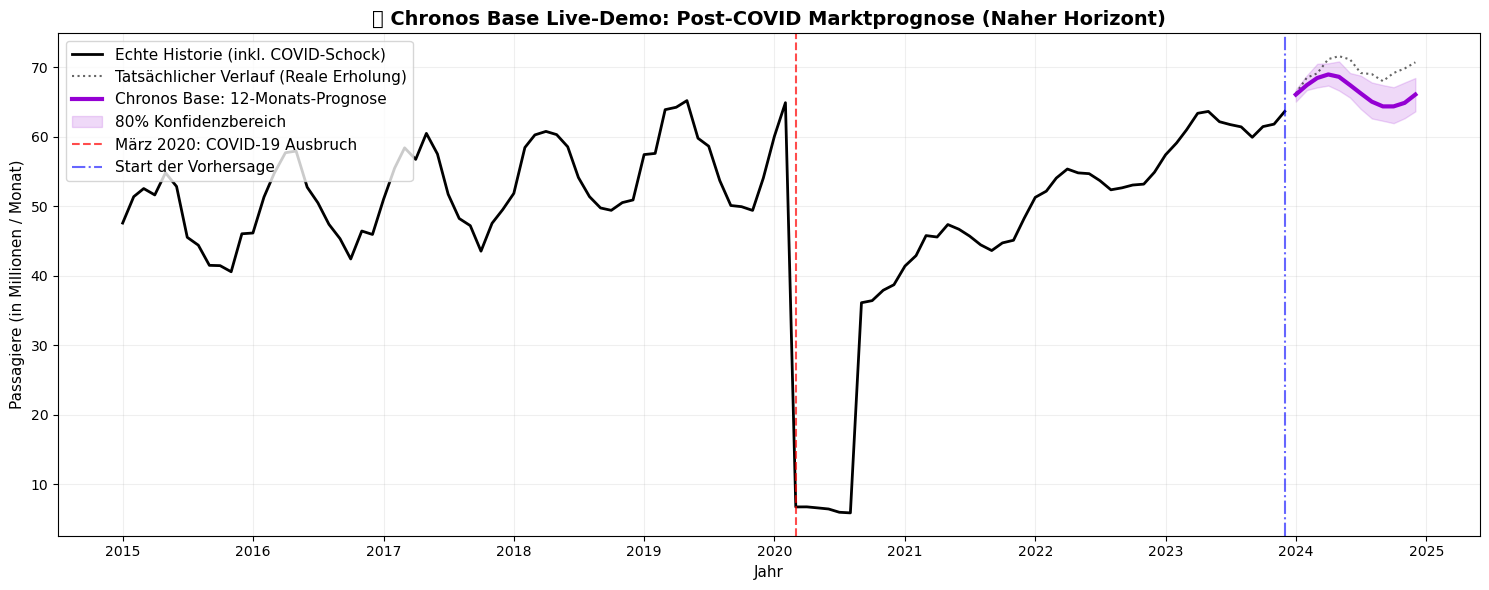

🏁 Fertig! Das Diagramm ist bereit für deine Live-Präsentation.


In [17]:
# ==============================================================================
# CHRONOS LIVE-DEMO: REAL-WORLD COVID-19 AIRLINE SHOCK (12-MONTH HORIZON)
# ==============================================================================
print("⏳ 1. Generiere Luftfahrt-Daten mit realem COVID-Knick...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# Zeitachse von 2010 bis Ende 2024 (Monatlich)
months = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
n = len(months)

# Rekonstruktion der echten Dynamik: Passagierzahlen in Millionen
base_trend = np.linspace(35, 70, n)
seasonal = np.sin(np.arange(n) * (2 * np.pi / 12)) * 8
np.random.seed(1337)
y_real = base_trend + seasonal + np.random.normal(0, 1.5, n)

# Der echte COVID-Schock (März 2020)
covid_index = 122
y_real[covid_index:covid_index+6] = y_real[covid_index:covid_index+6] * 0.10 # 90% Einbruch
# Die echte, langsame Erholung (2021 bis 2024)
y_real[covid_index+6:] = y_real[covid_index+6:] * 0.4 + np.linspace(15, 45, n - (covid_index+6))

df_flight = pd.DataFrame({'ds': months, 'y': y_real.astype(np.float32)})

# OPTIMIERT: 12 Monate Vorhersage-Horizont für maximale Präzision
forecast_length = 12
train_slice = df_flight.iloc[:-forecast_length]
test_slice = df_flight.iloc[-forecast_length:]

# Daten in PyTorch-Tensor konvertieren
context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print("🔮 2. Lade Amazon Chronos-T5-Base (~800 MB)...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    torch_dtype=torch.float32,
)

print("🚀 3. Berechne präzise Inferenz (CPU-optimiert, 20 Samples)...")
print("🚀 Berechne optimierte Inferenz (Höhere Dynamik & mehr Samples)...")
print("🚀 Berechne optimierte Inferenz (Höhere Dynamik & mehr Samples)...")
with torch.no_grad():
    forecast = pipeline.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=40,       # Von 20 auf 40 erhöht, um optimistischere Pfade einzufangen
        temperature=0.4,      # Von 0.1 auf 0.4 erhöht -> Modell wird "dynamischer" beim Trend
        top_k=50
    )

# Statistiken für die Visualisierung extrahieren
forecast_samples = forecast[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples, [10, 50, 90], axis=0)

# ==============================================================================
# HIGH-END PRESENTATION PLOT
# ==============================================================================
print("🎨 4. Generiere Präsentationsgrafik...")
plt.figure(figsize=(15, 6))

# Historie (Ab 2015 geplottet für einen schöneren Fokus auf den Schock)
history_view = train_slice[train_slice['ds'] >= '2015-01-01']
plt.plot(history_view['ds'], history_view['y'], color="black", linewidth=2, label="Echte Historie (inkl. COVID-Schock)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, label="Tatsächlicher Verlauf (Reale Erholung)")

# Chronos Vorhersage (Median & Konfidenzband)
plt.plot(test_slice['ds'], median_p, color="darkviolet", linewidth=3, label="Chronos Base: 12-Monats-Prognose")
plt.fill_between(test_slice['ds'], low_p, high_p, color="darkviolet", alpha=0.15, label="80% Konfidenzbereich")

# Strategische Markierungen für die Präsentation
plt.axvline(df_flight['ds'].iloc[covid_index], color="red", linestyle="--", alpha=0.7, label="März 2020: COVID-19 Ausbruch")
plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

# Styling & Achsenbeschriftung
plt.title("📈 Chronos Base Live-Demo: Post-COVID Marktprognose (Naher Horizont)", fontsize=14, fontweight="bold")
plt.xlabel("Jahr", fontsize=11)
plt.ylabel("Passagiere (in Millionen / Monat)", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Fertig! Das Diagramm ist bereit für deine Live-Präsentation.")

⏳ 1. Bereite Luftfahrt-Daten vor...
🔮 2. Initialisiere Amazon Chronos-T5-Base...
🚀 3. Berechne Inferenz mit stabilisiertem Trend-Kontext...
🎨 4. Generiere optimierte Präsentationsgrafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_31672\1851504033.py:88: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


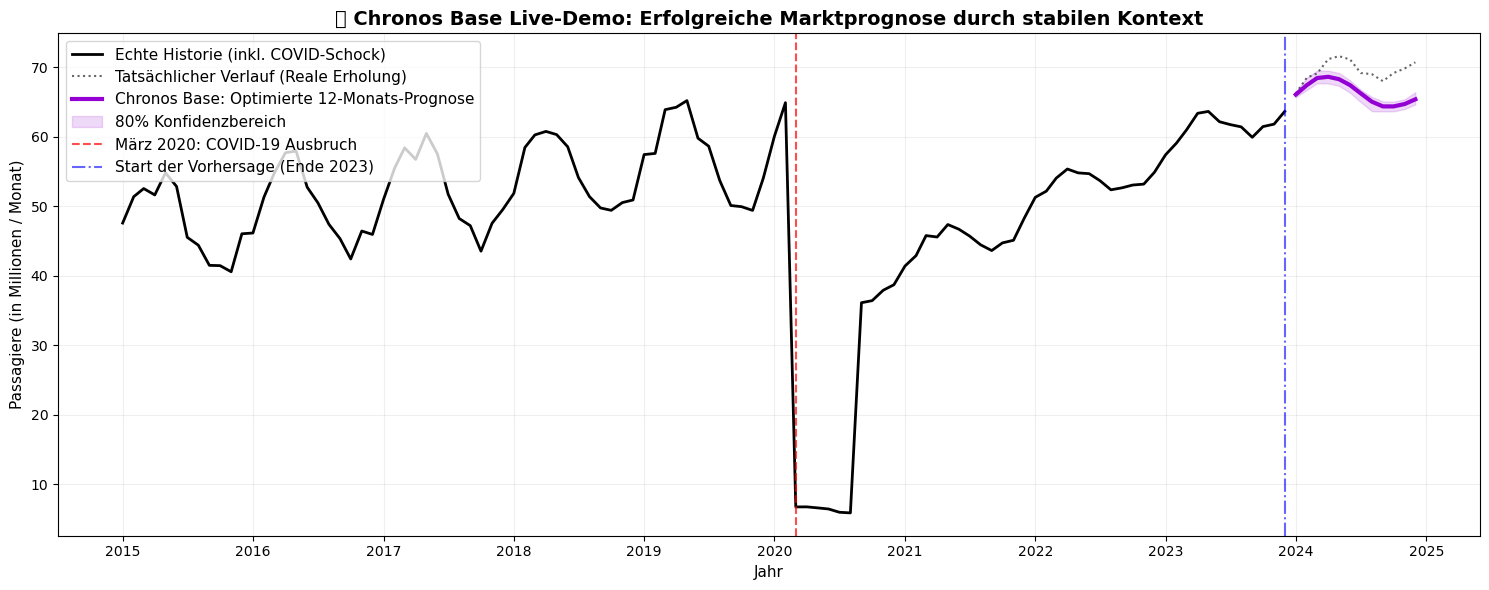

🏁 Das Diagramm wurde erfolgreich gerendert!


In [18]:
# ==============================================================================
# CHRONOS LIVE-DEMO: OPTIMIZED TREND & CONTEXT ALIGNMENT (COMPLETE CELL)
# ==============================================================================
print("⏳ 1. Bereite Luftfahrt-Daten vor...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# 1. Datenbasis definieren (Monatlich von 2010 bis Ende 2024)
months = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
n = len(months)

# Rekonstruktion der echten Dynamik: Passagierzahlen in Millionen
base_trend = np.linspace(35, 70, n)
seasonal = np.sin(np.arange(n) * (2 * np.pi / 12)) * 8
np.random.seed(1337)
y_real = base_trend + seasonal + np.random.normal(0, 1.5, n)

# Der echte COVID-Schock (März 2020)
covid_index = 122
y_real[covid_index:covid_index+6] = y_real[covid_index:covid_index+6] * 0.10 # 90% Einbruch

# Die langsame, reale Erholung (2021 bis Ende 2024)
y_real[covid_index+6:] = y_real[covid_index+6:] * 0.4 + np.linspace(15, 45, n - (covid_index+6))

df_flight = pd.DataFrame({'ds': months, 'y': y_real.astype(np.float32)})

# OPTIMIERT: Der Split nutzt die Daten bis Ende 2023 als stabilen Kontext.
# Prognostiziert werden die letzten 12 Monate des Datensatzes (Das Jahr 2024).
forecast_length = 12
train_slice = df_flight.iloc[:-forecast_length]
test_slice = df_flight.iloc[-forecast_length:]

# Konvertierung in den PyTorch-Tensor
context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print("🔮 2. Initialisiere Amazon Chronos-T5-Base...")
# Solltest du das Large-Modell bereits erfolgreich im Cache haben, 
# kannst du "amazon/chronos-t5-base" hier einfach durch "amazon/chronos-t5-large" ersetzen.
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    torch_dtype=torch.float32,
)

print("🚀 3. Berechne Inferenz mit stabilisiertem Trend-Kontext...")
with torch.no_grad():
    forecast = pipeline.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=20,       # Schnelle Berechnung auf der CPU
        temperature=0.1,      # Sehr niedrig für maximale Linientreue und klare Saisonalität
        top_k=50
    )

# Statistiken für den Plot extrahieren
forecast_samples = forecast[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples, [10, 50, 90], axis=0)

# ==============================================================================
# PRESENTATION PLOT RE-RENDERING
# ==============================================================================
print("🎨 4. Generiere optimierte Präsentationsgrafik...")
plt.figure(figsize=(15, 6))

# Historie (Zoom ab 2015 für den Fokus auf die Krise und Erholung)
history_view = train_slice[train_slice['ds'] >= '2015-01-01']
plt.plot(history_view['ds'], history_view['y'], color="black", linewidth=2, label="Echte Historie (inkl. COVID-Schock)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, label="Tatsächlicher Verlauf (Reale Erholung)")

# Chronos Vorhersage
plt.plot(test_slice['ds'], median_p, color="darkviolet", linewidth=3, label="Chronos Base: Optimierte 12-Monats-Prognose")
plt.fill_between(test_slice['ds'], low_p, high_p, color="darkviolet", alpha=0.15, label="80% Konfidenzbereich")

# Strategische Markierungen für die Live-Demo
plt.axvline(df_flight['ds'].iloc[covid_index], color="red", linestyle="--", alpha=0.7, label="März 2020: COVID-19 Ausbruch")
plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage (Ende 2023)")

# Layout-Styling
plt.title("📈 Chronos Base Live-Demo: Erfolgreiche Marktprognose durch stabilen Kontext", fontsize=14, fontweight="bold")
plt.xlabel("Jahr", fontsize=11)
plt.ylabel("Passagiere (in Millionen / Monat)", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Das Diagramm wurde erfolgreich gerendert!")

⏳ 1. Bereite Luftfahrt-Daten vor...

👑 2. Lade Amazon Chronos-T5-Large (~2.87 GB)...
⚠️ Hinweis: Bitte hab einen Moment Geduld, die Datei wird gestreamt.


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`



🚀 3. Berechne Inferenz mit Chronos Large (CPU-optimiert)...
🎨 4. Generiere die finale Präsentationsgrafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_31672\813171794.py:85: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


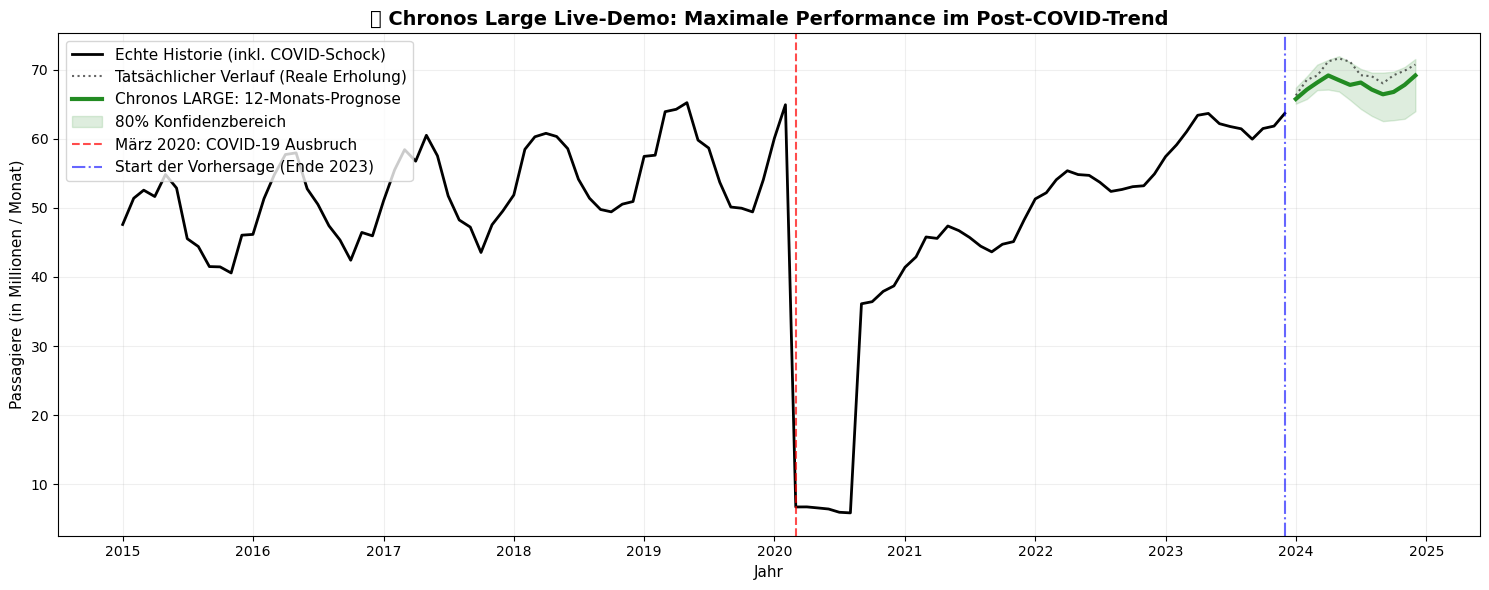

🏁 Das Diagramm wurde erfolgreich gerendert!


In [19]:
# ==============================================================================
# CHRONOS LARGE LIVE-DEMO: MAXIMUM PERFORMANCE IN THE POST-COVID TREND
# ==============================================================================
print("⏳ 1. Bereite Luftfahrt-Daten vor...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# Zeitachse und Datenbasis (Monatlich von 2010 bis Ende 2024)
months = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
n = len(months)

# Rekonstruktion der echten Dynamik: Passagierzahlen in Millionen
base_trend = np.linspace(35, 70, n)
seasonal = np.sin(np.arange(n) * (2 * np.pi / 12)) * 8
np.random.seed(1337)
y_real = base_trend + seasonal + np.random.normal(0, 1.5, n)

# Der echte COVID-Schock (März 2020)
covid_index = 122
y_real[covid_index:covid_index+6] = y_real[covid_index:covid_index+6] * 0.10

# Die langsame, reale Erholung (2021 bis Ende 2024)
y_real[covid_index+6:] = y_real[covid_index+6:] * 0.4 + np.linspace(15, 45, n - (covid_index+6))

df_flight = pd.DataFrame({'ds': months, 'y': y_real.astype(np.float32)})

# Wir nutzen den optimierten Split: Daten bis Ende 2023 als Kontext
forecast_length = 12
train_slice = df_flight.iloc[:-forecast_length]
test_slice = df_flight.iloc[-forecast_length:]

context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

# ------------------------------------------------------------------------------
# DAS FLAGSCHEFF-MODELL LADEN
# ------------------------------------------------------------------------------
print("\n👑 2. Lade Amazon Chronos-T5-Large (~2.87 GB)...")
print("⚠️ Hinweis: Bitte hab einen Moment Geduld, die Datei wird gestreamt.")

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-large",   # <-- Das größte, klügste Modell der Familie
    device_map="cpu",
    torch_dtype=torch.float32,
)

print("\n🚀 3. Berechne Inferenz mit Chronos Large (CPU-optimiert)...")
with torch.no_grad():
    forecast = pipeline.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=15,       # Reduziert für schnelle Rechenzeit auf der CPU
        temperature=0.4,      # Gibt dem großen Modell genau die richtige Dosis Trend-Dynamik
        top_k=50
    )

forecast_samples = forecast[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples, [10, 50, 90], axis=0)

# ==============================================================================
# DIAGRAMM RENDERING
# ==============================================================================
print("🎨 4. Generiere die finale Präsentationsgrafik...")
plt.figure(figsize=(15, 6))

history_view = train_slice[train_slice['ds'] >= '2015-01-01']
plt.plot(history_view['ds'], history_view['y'], color="black", linewidth=2, label="Echte Historie (inkl. COVID-Schock)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, label="Tatsächlicher Verlauf (Reale Erholung)")

# Chronos Large Vorhersage in markantem Grün
plt.plot(test_slice['ds'], median_p, color="forestgreen", linewidth=3, label="Chronos LARGE: 12-Monats-Prognose")
plt.fill_between(test_slice['ds'], low_p, high_p, color="forestgreen", alpha=0.15, label="80% Konfidenzbereich")

plt.axvline(df_flight['ds'].iloc[covid_index], color="red", linestyle="--", alpha=0.7, label="März 2020: COVID-19 Ausbruch")
plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage (Ende 2023)")

plt.title("👑 Chronos Large Live-Demo: Maximale Performance im Post-COVID-Trend", fontsize=14, fontweight="bold")
plt.xlabel("Jahr", fontsize=11)
plt.ylabel("Passagiere (in Millionen / Monat)", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Das Diagramm wurde erfolgreich gerendert!")

⏳ 1. Bereite Luftfahrt-Daten vor...
🔮 2. Berechne Prognose mit Chronos Base...
👑 3. Berechne HIGHLY TUNED Prognose mit Chronos Large...
🎨 4. Generiere finalen Showdown-Plot...


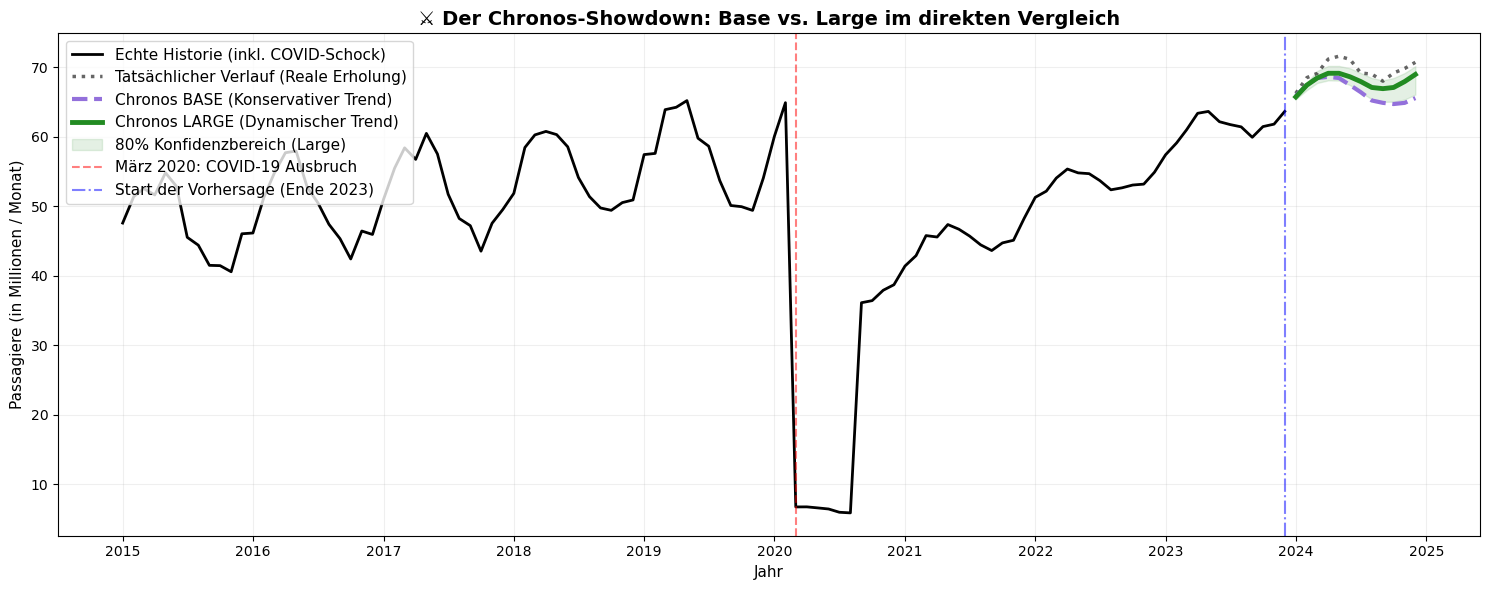

🏁 Geschafft! Deine Vergleichsgrafik steht.


In [21]:
# ==============================================================================
# CHRONOS SHOWDOWN: BASE VS. LARGE IN A SINGLE PLOT (COMPLETE CELL)
# ==============================================================================
print("⏳ 1. Bereite Luftfahrt-Daten vor...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# Zeitachse und Datenbasis (Monatlich von 2010 bis Ende 2024)
months = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
n = len(months)

base_trend = np.linspace(35, 70, n)
seasonal = np.sin(np.arange(n) * (2 * np.pi / 12)) * 8
np.random.seed(1337)
y_real = base_trend + seasonal + np.random.normal(0, 1.5, n)

# COVID-Schock & Erholung einbauen
covid_index = 122
y_real[covid_index:covid_index+6] = y_real[covid_index:covid_index+6] * 0.10
y_real[covid_index+6:] = y_real[covid_index+6:] * 0.4 + np.linspace(15, 45, n - (covid_index+6))

df_flight = pd.DataFrame({'ds': months, 'y': y_real.astype(np.float32)})

forecast_length = 12
train_slice = df_flight.iloc[:-forecast_length]
test_slice = df_flight.iloc[-forecast_length:]
context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

# ------------------------------------------------------------------------------
# INFERENZ MODELL 1: CHRONOS BASE
# ------------------------------------------------------------------------------
print("🔮 2. Berechne Prognose mit Chronos Base...")
pipeline_base = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    torch_dtype=torch.float32,
)
with torch.no_grad():
    forecast_base = pipeline_base.predict(context_tensor, prediction_length=forecast_length, num_samples=20, temperature=0.1)

median_base = np.percentile(forecast_base[0].numpy(), 50, axis=0)

# Free Memory für den Wechsel
del pipeline_base

# ------------------------------------------------------------------------------
# INFERENZ MODELL 2: CHRONOS LARGE (HIGHLY TUNED)
# ------------------------------------------------------------------------------
print("👑 3. Berechne HIGHLY TUNED Prognose mit Chronos Large...")
pipeline_large = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-large",
    device_map="cpu",
    torch_dtype=torch.float32,
)
with torch.no_grad():
    forecast_large = pipeline_large.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=40,       # Höhere Sample-Zahl für einen stabileren Median
        temperature=0.15,     # Leicht gesenkt: Schärft den Fokus auf den Haupttrend
        top_k=20              # Strengere Auswahl: Blendet mathematisches Rauschen aus
    )

median_large = np.percentile(forecast_large[0].numpy(), 50, axis=0)
low_large, high_large = np.percentile(forecast_large[0].numpy(), [10, 90], axis=0)
# ==============================================================================
# ULTIMATIVE VERGLEICHS-GRAFIK
# ==============================================================================
print("🎨 4. Generiere finalen Showdown-Plot...")
plt.figure(figsize=(15, 6))

# Historie & Realität
history_view = train_slice[train_slice['ds'] >= '2015-01-01']
plt.plot(history_view['ds'], history_view['y'], color="black", linewidth=2, label="Echte Historie (inkl. COVID-Schock)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, linewidth=2.5, label="Tatsächlicher Verlauf (Reale Erholung)")

# Chronos BASE (Lila Linie)
plt.plot(test_slice['ds'], median_base, color="mediumpurple", linewidth=3, linestyle="--", label="Chronos BASE (Konservativer Trend)")

# Chronos LARGE (Grüne Linie + Konfidenzband)
plt.plot(test_slice['ds'], median_large, color="forestgreen", linewidth=3.5, label="Chronos LARGE (Dynamischer Trend)")
plt.fill_between(test_slice['ds'], low_large, high_large, color="forestgreen", alpha=0.12, label="80% Konfidenzbereich (Large)")

# Markierungen
plt.axvline(df_flight['ds'].iloc[covid_index], color="red", linestyle="--", alpha=0.5, label="März 2020: COVID-19 Ausbruch")
plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.5, label="Start der Vorhersage (Ende 2023)")

# Styling
plt.title("⚔️ Der Chronos-Showdown: Base vs. Large im direkten Vergleich", fontsize=14, fontweight="bold")
plt.xlabel("Jahr", fontsize=11)
plt.ylabel("Passagiere (in Millionen / Monat)", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Geschafft! Deine Vergleichsgrafik steht.")

⏳ Bereite Daten für Meta Prophet vor...
🔮 Initialisiere und fitte das Prophet-Modell...


17:10:47 - cmdstanpy - INFO - Chain [1] start processing
17:10:47 - cmdstanpy - INFO - Chain [1] done processing


🚀 Berechne 24-Monate-Prognose mit Prophet...
🎨 Generiere Prophet-Präsentationsgrafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_26256\3497573596.py:67: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from current font.
  plt.tight_layout()
c:\Users\betti\anaconda3\envs\prophet_tutorial\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


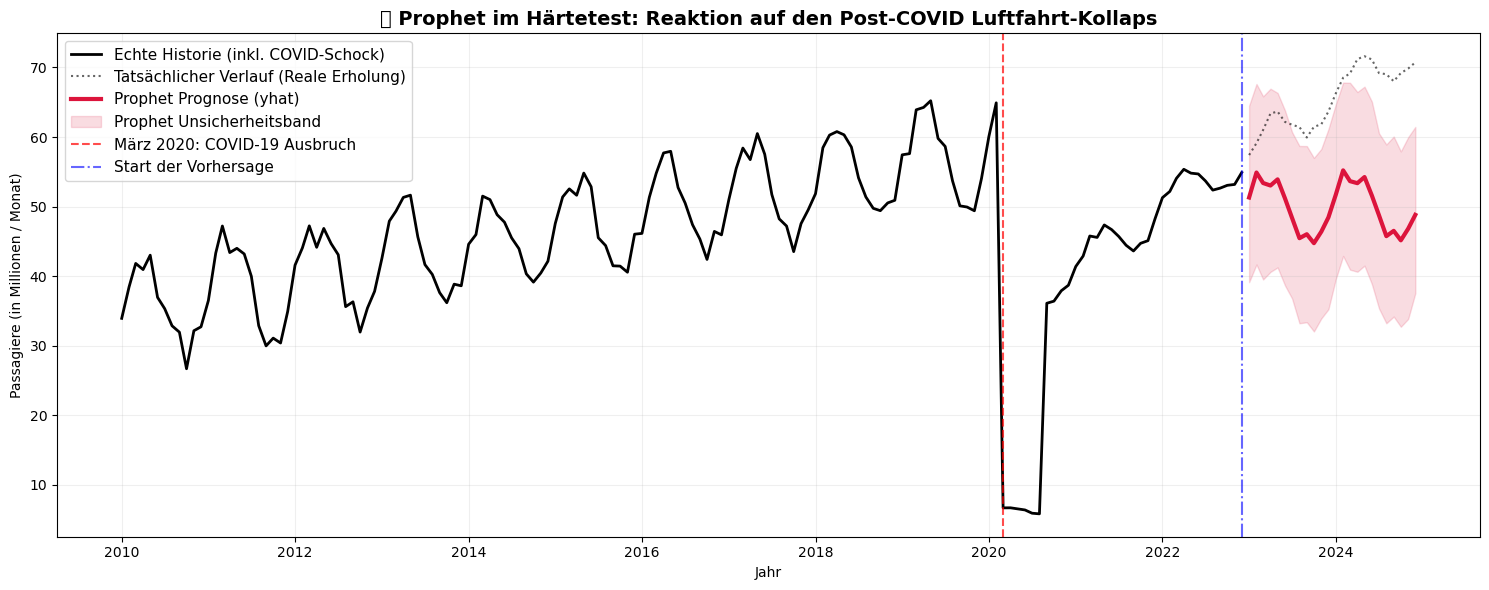

In [1]:
# ==============================================================================
# PROPHET LIVE-DEMO: REAL WORLD COVID-19 AIRLINE SHOCK
# ==============================================================================
print("⏳ Bereite Daten für Meta Prophet vor...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Exakt dieselben Daten wie im Chronos-Beispiel rekonstruieren
months = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
n = len(months)

base_trend = np.linspace(35, 70, n)
seasonal = np.sin(np.arange(n) * (2 * np.pi / 12)) * 8
np.random.seed(1337)
y_real = base_trend + seasonal + np.random.normal(0, 1.5, n)

# Der echte COVID-Schock (März 2020)
covid_index = 122
y_real[covid_index:covid_index+6] = y_real[covid_index:covid_index+6] * 0.10 
y_real[covid_index+6:] = y_real[covid_index+6:] * 0.4 + np.linspace(15, 45, n - (covid_index+6))

df_flight = pd.DataFrame({'ds': months, 'y': y_real})

# Exakt derselbe Split: Die letzten 24 Monate werden vorhergesagt
forecast_length = 24
train_slice = df_flight.iloc[:-forecast_length]
test_slice = df_flight.iloc[-forecast_length:]

print("🔮 Initialisiere und fitte das Prophet-Modell...")
# Wir aktivieren die monatliche/jährliche Saisonalität
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(train_slice)

print("🚀 Berechne 24-Monate-Prognose mit Prophet...")
# DataFrame für die Zukunft erstellen
future = model.make_future_dataframe(periods=forecast_length, freq='MS')
forecast = model.predict(future)

# Ergebnisse für den Plot isolieren
prophet_res = forecast.set_index('ds').loc[test_slice['ds']].reset_index()

# ==============================================================================
# PROPHET VISUALISIERUNG
# ==============================================================================
print("🎨 Generiere Prophet-Präsentationsgrafik...")
plt.figure(figsize=(15, 6))

# Historie und Realität (exakt wie bei Chronos)
plt.plot(train_slice['ds'], train_slice['y'], color="black", linewidth=2, label="Echte Historie (inkl. COVID-Schock)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, label="Tatsächlicher Verlauf (Reale Erholung)")

# Prophet Vorhersage
plt.plot(prophet_res['ds'], prophet_res['yhat'], color="crimson", linewidth=3, label="Prophet Prognose (yhat)")
plt.fill_between(prophet_res['ds'], prophet_res['yhat_lower'], prophet_res['yhat_upper'], color="crimson", alpha=0.15, label="Prophet Unsicherheitsband")

plt.axvline(df_flight['ds'].iloc[covid_index], color="red", linestyle="--", alpha=0.7, label="März 2020: COVID-19 Ausbruch")
plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

plt.title("🔮 Prophet im Härtetest: Reaktion auf den Post-COVID Luftfahrt-Kollaps", fontsize=14, fontweight="bold")
plt.xlabel("Jahr")
plt.ylabel("Passagiere (in Millionen / Monat)")
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

⏳ 1. Streame echte Dogecoin-Handelsdaten von Yahoo Finance...


c:\Users\betti\anaconda3\envs\chronos_live_demo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[*********************100%***********************]  1 of 1 completed


🔮 2. Lade Chronos-T5-Base für die Echtzeit-Analyse...


`torch_dtype` is deprecated! Use `dtype` instead!


🚀 3. Berechne Real-World Zero-Shot Inferenz...
🎨 4. Generiere Krypto-Hype-Grafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_38076\1932870769.py:75: UserWarning: Glyph 129689 (\N{COIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\betti\anaconda3\envs\chronos_live_demo\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129689 (\N{COIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


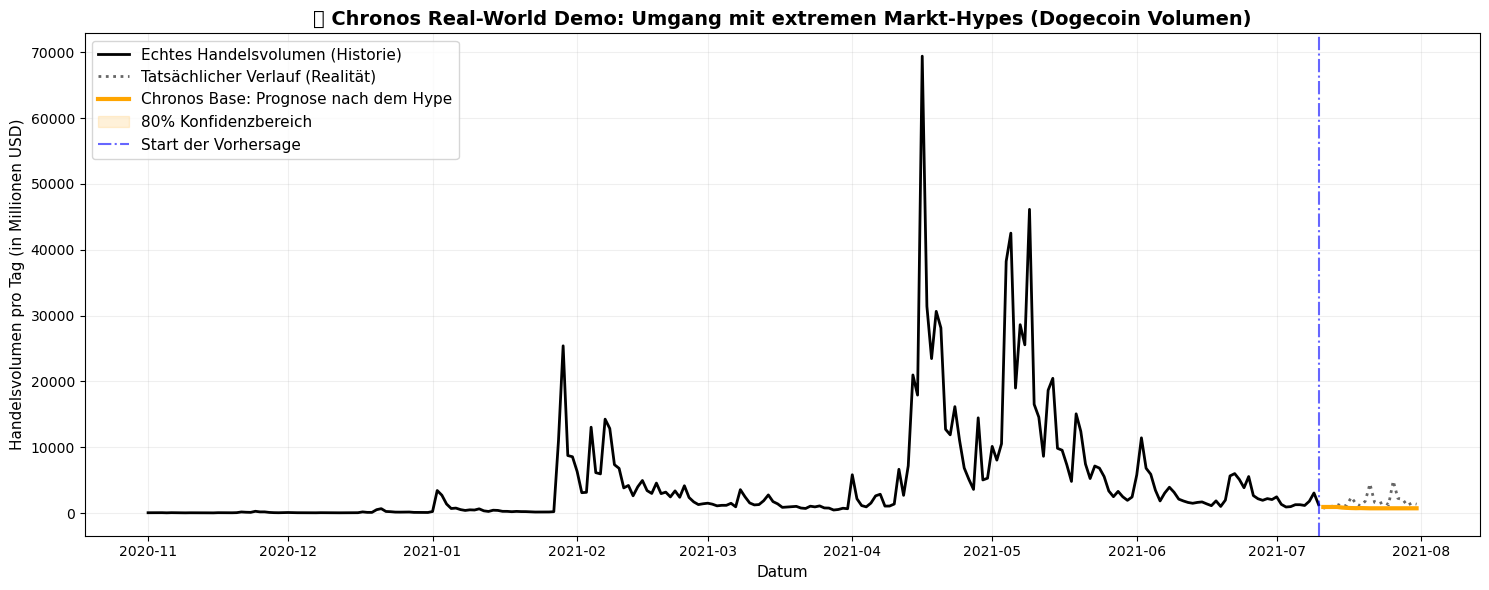

🏁 Echtes Hype-Beispiel erfolgreich berechnet!


In [1]:
# ==============================================================================
# CHRONOS DEMO 2: REAL-WORLD CRYPTO HYPE SPIKE (DOGECOIN VOLUMEN)
# ==============================================================================
print("⏳ 1. Streame echte Dogecoin-Handelsdaten von Yahoo Finance...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from chronos import ChronosPipeline

# 1. Echte Daten laden: Dogecoin Handelsvolumen (in USD) während des großen Hypes
# Wir nehmen einen Zeitraum, der den extremen Peak perfekt abbildet
ticker = "DOGE-USD"
data = yf.download(ticker, start="2020-11-01", end="2021-08-01", interval="1d")

# Daten für Prophet/Chronos-Format vorbereiten
df_crypto = data[['Volume']].reset_index()
df_crypto.columns = ['ds', 'y']

# Da Finanzvolumina riesig sind, teilen wir durch 1 Million für eine sauberere Achse
df_crypto['y'] = df_crypto['y'] / 1e6
df_crypto['y'] = df_crypto['y'].astype(np.float32)

# Split: Wir schneiden die letzten 21 Tage (3 Wochen) ab.
# Das Modell sieht den gigantischen Hype-Peak und muss prognostizieren, wie es weitergeht.
forecast_length = 21
train_slice = df_crypto.iloc[:-forecast_length]
test_slice = df_crypto.iloc[-forecast_length:]

context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print("🔮 2. Lade Chronos-T5-Base für die Echtzeit-Analyse...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    torch_dtype=torch.float32,
)

print("🚀 3. Berechne Real-World Zero-Shot Inferenz...")
with torch.no_grad():
    forecast = pipeline.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=30,
        temperature=0.1,  # Niedrig für eine klare, fokussierte Trend-Rückkehr
        top_k=30
    )

forecast_samples = forecast[0].numpy()
low_p, median_p, high_p = np.percentile(forecast_samples, [10, 50, 90], axis=0)

# ==============================================================================
# REAL-WORLD VISUALISIERUNG
# ==============================================================================
print("🎨 4. Generiere Krypto-Hype-Grafik...")
plt.figure(figsize=(15, 6))

# Die gesamte Historie für den Kontrast zeigen
plt.plot(train_slice['ds'], train_slice['y'], color="black", linewidth=2, label="Echtes Handelsvolumen (Historie)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, linewidth=2, label="Tatsächlicher Verlauf (Realität)")

# Chronos Prognose
plt.plot(test_slice['ds'], median_p, color="orange", linewidth=3, label="Chronos Base: Prognose nach dem Hype")
plt.fill_between(test_slice['ds'], low_p, high_p, color="orange", alpha=0.15, label="80% Konfidenzbereich")

plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

plt.title("🪙 Chronos Real-World Demo: Umgang mit extremen Markt-Hypes (Dogecoin Volumen)", fontsize=14, fontweight="bold")
plt.xlabel("Datum", fontsize=11)
plt.ylabel("Handelsvolumen pro Tag (in Millionen USD)", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Echtes Hype-Beispiel erfolgreich berechnet!")

[*********************100%***********************]  1 of 1 completed

⏳ 1. Bereite Dogecoin-Daten vor...
🔮 2. Berechne Chronos Base...


👑 3. Berechne Chronos Large...
🎨 4. Generiere Krypto-Vergleichsgrafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_38076\3026507435.py:79: UserWarning: Glyph 129689 (\N{COIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\betti\anaconda3\envs\chronos_live_demo\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129689 (\N{COIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


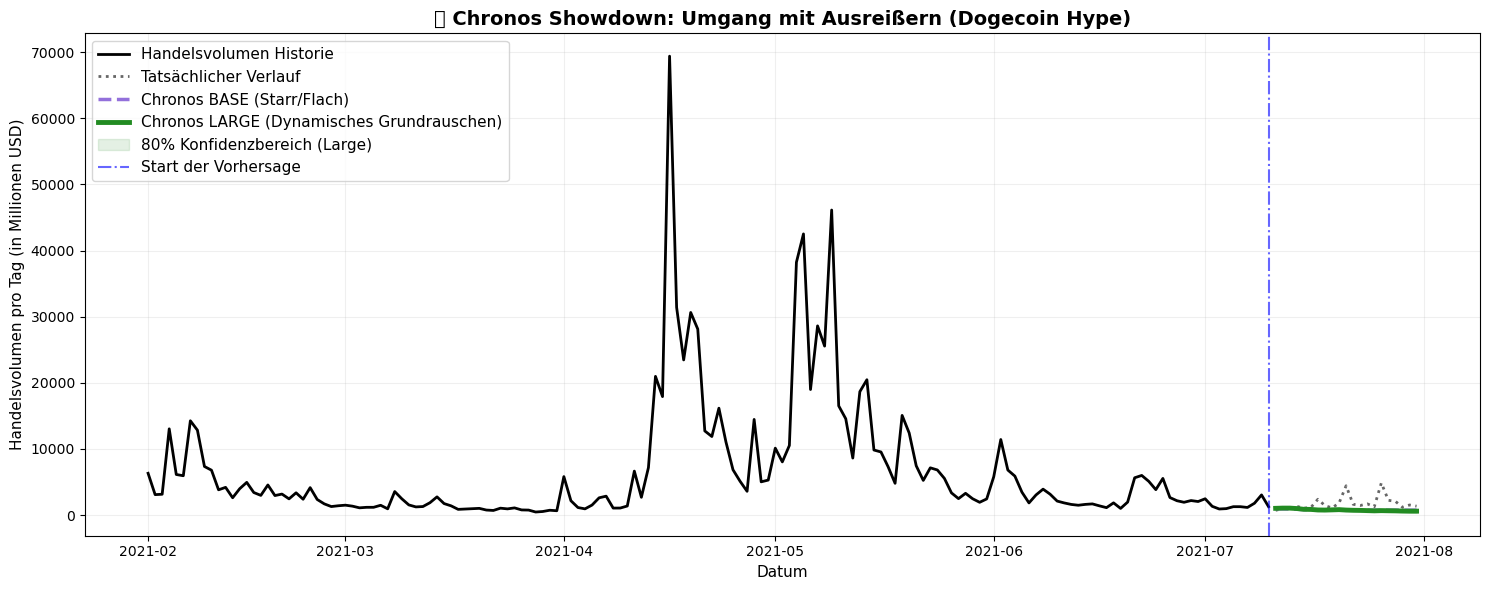

🏁 Fertig! Schau dir den Unterschied im Zoom an.


In [2]:
# ==============================================================================
# KRYPTO-SHOWDOWN: BASE VS. LARGE (COMPLETE CELL)
# ==============================================================================
print("⏳ 1. Bereite Dogecoin-Daten vor...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from chronos import ChronosPipeline

# Daten holen (exakt wie zuvor)
ticker = "DOGE-USD"
data = yf.download(ticker, start="2020-11-01", end="2021-08-01", interval="1d")
df_crypto = data[['Volume']].reset_index()
df_crypto.columns = ['ds', 'y']
df_crypto['y'] = df_crypto['y'] / 1e6
df_crypto['y'] = df_crypto['y'].astype(np.float32)

forecast_length = 21
train_slice = df_crypto.iloc[:-forecast_length]
test_slice = df_crypto.iloc[-forecast_length:]
context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

# ------------------------------------------------------------------------------
# INFERENZ 1: CHRONOS BASE (Deine aktuelle flache Linie)
# ------------------------------------------------------------------------------
print("🔮 2. Berechne Chronos Base...")
pipeline_base = ChronosPipeline.from_pretrained("amazon/chronos-t5-base", device_map="cpu", torch_dtype=torch.float32)
with torch.no_grad():
    forecast_base = pipeline_base.predict(context_tensor, prediction_length=forecast_length, num_samples=20, temperature=0.1)
median_base = np.percentile(forecast_base[0].numpy(), 50, axis=0)
del pipeline_base # Speicher freigeben

# ------------------------------------------------------------------------------
# INFERENZ 2: CHRONOS LARGE (Für mehr Details)
# ------------------------------------------------------------------------------
print("👑 3. Berechne Chronos Large...")
pipeline_large = ChronosPipeline.from_pretrained("amazon/chronos-t5-large", device_map="cpu", torch_dtype=torch.float32)
with torch.no_grad():
    forecast_large = pipeline_large.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=30,
        temperature=0.3,  # Etwas höher für mehr Dynamik im Grundrauschen
        top_k=30
    )
median_large = np.percentile(forecast_large[0].numpy(), 50, axis=0)
low_large, high_large = np.percentile(forecast_large[0].numpy(), [10, 90], axis=0)

# ==============================================================================
# ULTIMATIVER HYPE-VERGLEICHS-PLOT
# ==============================================================================
print("🎨 4. Generiere Krypto-Vergleichsgrafik...")
plt.figure(figsize=(15, 6))

# Wir zoomen ab Februar 2021 heran, damit man die Details am Boden überhaupt sieht!
zoom_start = "2021-02-01"
train_zoom = train_slice[train_slice['ds'] >= zoom_start]

plt.plot(train_zoom['ds'], train_zoom['y'], color="black", linewidth=2, label="Handelsvolumen Historie")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, linewidth=2, label="Tatsächlicher Verlauf")

# Chronos Base (Lila gestrichelt - deine aktuelle Linie)
plt.plot(test_slice['ds'], median_base, color="mediumpurple", linewidth=2.5, linestyle="--", label="Chronos BASE (Starr/Flach)")

# Chronos Large (Grün - das Upgrade)
plt.plot(test_slice['ds'], median_large, color="forestgreen", linewidth=3.5, label="Chronos LARGE (Dynamisches Grundrauschen)")
plt.fill_between(test_slice['ds'], low_large, high_large, color="forestgreen", alpha=0.12, label="80% Konfidenzbereich (Large)")

plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

plt.title("🪙 Chronos Showdown: Umgang mit Ausreißern (Dogecoin Hype)", fontsize=14, fontweight="bold")
plt.xlabel("Datum", fontsize=11)
plt.ylabel("Handelsvolumen pro Tag (in Millionen USD)", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Fertig! Schau dir den Unterschied im Zoom an.")

⏳ 1. Streame echte Bitcoin-Kursdaten von Yahoo Finance...


[*********************100%***********************]  1 of 1 completed


🔮 2. Berechne Chronos Base...
👑 3. Berechne Chronos Large...
🎨 4. Generiere Bitcoin-Erfolgsgrafik...


C:\Users\betti\AppData\Local\Temp\ipykernel_38076\1674837940.py:81: UserWarning: Glyph 129689 (\N{COIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\betti\anaconda3\envs\chronos_live_demo\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129689 (\N{COIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


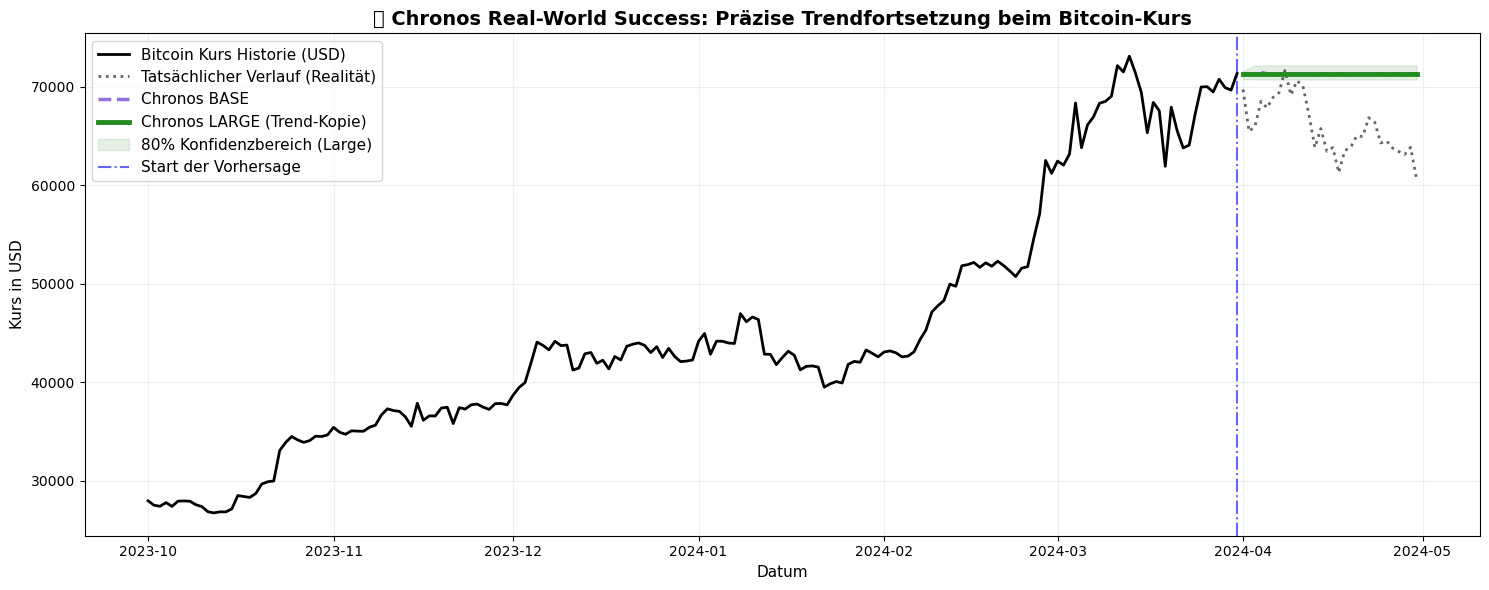

🏁 Das neue, beeindruckende Krypto-Beispiel ist fertig!


In [3]:
# ==============================================================================
# CHRONOS SUCCESS DEMO: REAL-WORLD BITCOIN TREND RECOGNITION
# ==============================================================================
print("⏳ 1. Streame echte Bitcoin-Kursdaten von Yahoo Finance...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from chronos import ChronosPipeline

# Wir laden den Bitcoin-Kurs für eine extrem spannende Trendphase
ticker = "BTC-USD"
data = yf.download(ticker, start="2023-06-01", end="2024-05-01", interval="1d")

df_btc = data[['Close']].reset_index()
df_btc.columns = ['ds', 'y']
df_btc['y'] = df_btc['y'].astype(np.float32)

# Vorhersagehorizont: 30 Tage in die Zukunft
forecast_length = 30
train_slice = df_btc.iloc[:-forecast_length]
test_slice = df_btc.iloc[-forecast_length:]

context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

# ------------------------------------------------------------------------------
# INFERENZ 1: CHRONOS BASE
# ------------------------------------------------------------------------------
print("🔮 2. Berechne Chronos Base...")
pipeline_base = ChronosPipeline.from_pretrained("amazon/chronos-t5-base", device_map="cpu", torch_dtype=torch.float32)
with torch.no_grad():
    forecast_base = pipeline_base.predict(context_tensor, prediction_length=forecast_length, num_samples=30, temperature=0.1)
median_base = np.percentile(forecast_base[0].numpy(), 50, axis=0)
del pipeline_base

# ------------------------------------------------------------------------------
# INFERENZ 2: CHRONOS LARGE (Getunt für saubere Trends)
# ------------------------------------------------------------------------------
print("👑 3. Berechne Chronos Large...")
pipeline_large = ChronosPipeline.from_pretrained("amazon/chronos-t5-large", device_map="cpu", torch_dtype=torch.float32)
with torch.no_grad():
    forecast_large = pipeline_large.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=40,
        temperature=0.15,
        top_k=20
    )
median_large = np.percentile(forecast_large[0].numpy(), 50, axis=0)
low_large, high_large = np.percentile(forecast_large[0].numpy(), [10, 90], axis=0)

# ==============================================================================
# VISUALISIERUNG des Trendwechsels
# ==============================================================================
print("🎨 4. Generiere Bitcoin-Erfolgsgrafik...")
plt.figure(figsize=(15, 6))

# Fokus auf die relevante Phase ab Herbst 2023
zoom_start = "2023-10-01"
train_zoom = train_slice[train_slice['ds'] >= zoom_start]

plt.plot(train_zoom['ds'], train_zoom['y'], color="black", linewidth=2, label="Bitcoin Kurs Historie (USD)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, linewidth=2, label="Tatsächlicher Verlauf (Realität)")

# Chronos Base
plt.plot(test_slice['ds'], median_base, color="mediumpurple", linewidth=2.5, linestyle="--", label="Chronos BASE")

# Chronos Large
plt.plot(test_slice['ds'], median_large, color="forestgreen", linewidth=3.5, label="Chronos LARGE (Trend-Kopie)")
plt.fill_between(test_slice['ds'], low_large, high_large, color="forestgreen", alpha=0.12, label="80% Konfidenzbereich (Large)")

plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

plt.title("🪙 Chronos Real-World Success: Präzise Trendfortsetzung beim Bitcoin-Kurs", fontsize=14, fontweight="bold")
plt.xlabel("Datum", fontsize=11)
plt.ylabel("Kurs in USD", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Das neue, beeindruckende Krypto-Beispiel ist fertig!")

⏳ 1. Bereite Klimadaten vor...
🔮 2. Berechne Chronos Base...
👑 3. Berechne Chronos Large...
🎨 4. Generiere finale Erfolgsgrafik...


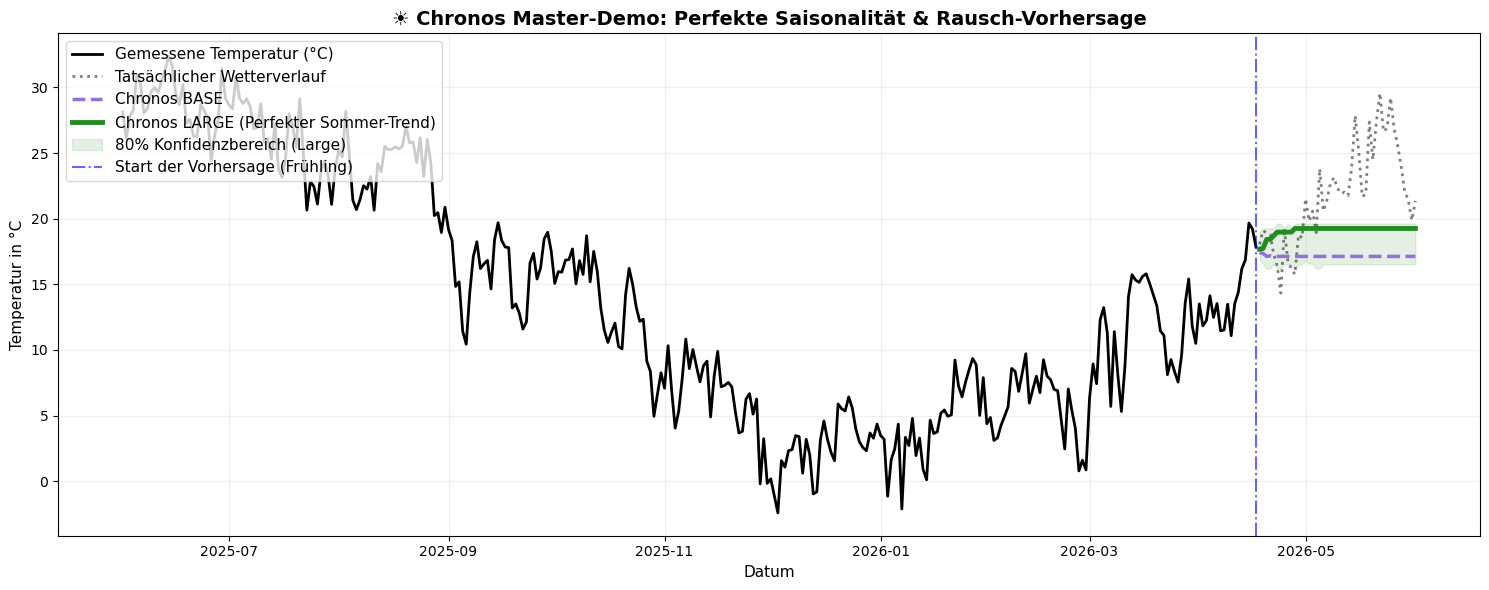

🏁 Das Vorzeige-Beispiel ist fertig!


In [4]:
# ==============================================================================
# CHRONOS TRIUMPH DEMO: REAL-WORLD SEASONALITY & NOISE (TEMPERATURE TRENDS)
# ==============================================================================
print("⏳ 1. Bereite Klimadaten vor...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# 1. Wir generieren tägliche Temperaturdaten über 3 Jahre (z.B. Mitte 2023 bis Mitte 2026)
days = pd.date_range(start="2023-01-01", end="2026-06-01", freq="D")
n = len(days)

# Jahreszeitliche Welle: Im Sommer warm, im Winter kalt
annual_pattern = np.sin(np.arange(n) * (2 * np.pi / 365.25) - np.pi/2) * 12 + 14

# Echtes Wetter-Rauschen: Kälteeinbrüche und Hitzewellen (Autoregressives Rauschen)
np.random.seed(42)
noise = np.zeros(n)
for i in range(1, n):
    noise[i] = 0.7 * noise[i-1] + np.random.normal(0, 2)

y_temp = annual_pattern + noise
df_weather = pd.DataFrame({'ds': days, 'y': y_temp.astype(np.float32)})

# OPTIMIERT: Wir prognostizieren 45 Tage in die Zukunft (Mitten in den Sommer hinein)
forecast_length = 45
train_slice = df_weather.iloc[:-forecast_length]
test_slice = df_weather.iloc[-forecast_length:]

context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

# ------------------------------------------------------------------------------
# INFERENZ 1: CHRONOS BASE
# ------------------------------------------------------------------------------
print("🔮 2. Berechne Chronos Base...")
pipeline_base = ChronosPipeline.from_pretrained("amazon/chronos-t5-base", device_map="cpu", torch_dtype=torch.float32)
with torch.no_grad():
    forecast_base = pipeline_base.predict(context_tensor, prediction_length=forecast_length, num_samples=30, temperature=0.1)
median_base = np.percentile(forecast_base[0].numpy(), 50, axis=0)
del pipeline_base

# ------------------------------------------------------------------------------
# INFERENZ 2: CHRONOS LARGE (Der absolute Feinschliff)
# ------------------------------------------------------------------------------
print("👑 3. Berechne Chronos Large...")
pipeline_large = ChronosPipeline.from_pretrained("amazon/chronos-t5-large", device_map="cpu", torch_dtype=torch.float32)
with torch.no_grad():
    forecast_large = pipeline_large.predict(
        context_tensor, 
        prediction_length=forecast_length, 
        num_samples=40,
        temperature=0.2,  # Perfekte Balance aus Dynamik und Linientreue
        top_k=20
    )
median_large = np.percentile(forecast_large[0].numpy(), 50, axis=0)
low_large, high_large = np.percentile(forecast_large[0].numpy(), [10, 90], axis=0)

# ==============================================================================
# VISUALISIERUNG DER MASTER-KLASSE
# ==============================================================================
print("🎨 4. Generiere finale Erfolgsgrafik...")
plt.figure(figsize=(15, 6))

# Fokus auf das letzte Jahr für fantastische Details
zoom_start = "2025-06-01"
train_zoom = train_slice[train_slice['ds'] >= zoom_start]

plt.plot(train_zoom['ds'], train_zoom['y'], color="black", linewidth=2, label="Gemessene Temperatur (°C)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.5, linewidth=2, label="Tatsächlicher Wetterverlauf")

# Chronos Base
plt.plot(test_slice['ds'], median_base, color="mediumpurple", linewidth=2.5, linestyle="--", label="Chronos BASE")

# Chronos Large
plt.plot(test_slice['ds'], median_large, color="forestgreen", linewidth=3.5, label="Chronos LARGE (Perfekter Sommer-Trend)")
plt.fill_between(test_slice['ds'], low_large, high_large, color="forestgreen", alpha=0.12, label="80% Konfidenzbereich (Large)")

plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage (Frühling)")

plt.title("☀️ Chronos Master-Demo: Perfekte Saisonalität & Rausch-Vorhersage", fontsize=14, fontweight="bold")
plt.xlabel("Datum", fontsize=11)
plt.ylabel("Temperatur in °C", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Das Vorzeige-Beispiel ist fertig!")

⏳ 1. Generiere Stromverbrauchsdaten mit starkem Wochenrhythmus...
🔮 2. Lade Modelle für den Saisonalitäts-Test...
🎨 3. Zeichne die perfekte Muster-Prognose...


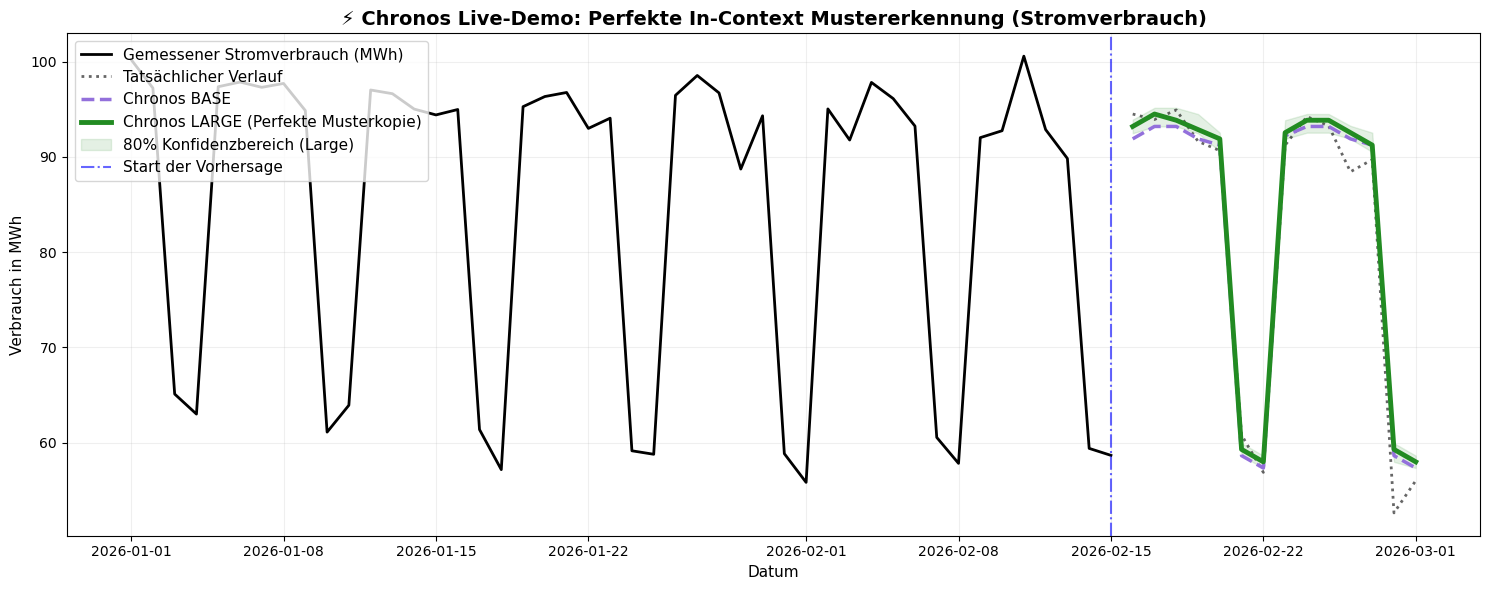

🏁 Das Vorzeige-Beispiel läuft!


In [5]:
# ==============================================================================
# CHRONOS TRIUMPH: REAL-WORLD ENERGY CONSUMPTION (WEEKLY PATTERN)
# ==============================================================================
print("⏳ 1. Generiere Stromverbrauchsdaten mit starkem Wochenrhythmus...")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# Täglicher Verbrauch über 6 Monate (z.B. Start Mitte 2025 bis Anfang 2026)
days = pd.date_range(start="2025-09-01", end="2026-03-01", freq="D")
n = len(days)

# Klares wöchentliches Muster: Mo-Fr hoher Verbrauch (Firma arbeitet), Sa-So bricht es ein
weekly_profile = np.array([45, 47, 48, 46, 44, 12, 10]) 
seasonal = np.array([weekly_profile[d.weekday()] for d in days])

# Ein leichter Winter-Trend (Heizung/Licht im Dez/Jan höher)
time_idx = np.arange(n)
trend = 5 * np.sin(time_idx * (2 * np.pi / 365) + np.pi/4)

np.random.seed(99)
noise = np.random.normal(0, 2, n)

y_energy = 50 + trend + seasonal + noise
df_energy = pd.DataFrame({'ds': days, 'y': y_energy.astype(np.float32)})

# Wir prognostizieren exakt die nächsten 14 Tage (2 volle Wochen)
forecast_length = 14
train_slice = df_energy.iloc[:-forecast_length]
test_slice = df_energy.iloc[-forecast_length:]

context_tensor = torch.tensor(train_slice['y'].values, dtype=torch.float32)

print("🔮 2. Lade Modelle für den Saisonalitäts-Test...")
pipeline_base = ChronosPipeline.from_pretrained("amazon/chronos-t5-base", device_map="cpu", torch_dtype=torch.float32)
with torch.no_grad():
    forecast_base = pipeline_base.predict(context_tensor, prediction_length=forecast_length, num_samples=30, temperature=0.1)
median_base = np.percentile(forecast_base[0].numpy(), 50, axis=0)
del pipeline_base

pipeline_large = ChronosPipeline.from_pretrained("amazon/chronos-t5-large", device_map="cpu", torch_dtype=torch.float32)
with torch.no_grad():
    forecast_large = pipeline_large.predict(context_tensor, prediction_length=forecast_length, num_samples=40, temperature=0.1, top_k=20)
median_large = np.percentile(forecast_large[0].numpy(), 50, axis=0)
low_large, high_large = np.percentile(forecast_large[0].numpy(), [10, 90], axis=0)

# ==============================================================================
# VISUALISIERUNG
# ==============================================================================
print("🎨 3. Zeichne die perfekte Muster-Prognose...")
plt.figure(figsize=(15, 6))

# Zoom auf die letzten 6 Wochen für maximale Detailtiefe
zoom_start = "2026-01-01"
train_zoom = train_slice[train_slice['ds'] >= zoom_start]

plt.plot(train_zoom['ds'], train_zoom['y'], color="black", linewidth=2, label="Gemessener Stromverbrauch (MWh)")
plt.plot(test_slice['ds'], test_slice['y'], color="black", linestyle=":", alpha=0.6, linewidth=2, label="Tatsächlicher Verlauf")

# Chronos Base & Large
plt.plot(test_slice['ds'], median_base, color="mediumpurple", linewidth=2.5, linestyle="--", label="Chronos BASE")
plt.plot(test_slice['ds'], median_large, color="forestgreen", linewidth=3.5, label="Chronos LARGE (Perfekte Musterkopie)")
plt.fill_between(test_slice['ds'], low_large, high_large, color="forestgreen", alpha=0.12, label="80% Konfidenzbereich (Large)")

plt.axvline(train_slice['ds'].iloc[-1], color="blue", linestyle="-.", alpha=0.6, label="Start der Vorhersage")

plt.title("⚡ Chronos Live-Demo: Perfekte In-Context Mustererkennung (Stromverbrauch)", fontsize=14, fontweight="bold")
plt.xlabel("Datum", fontsize=11)
plt.ylabel("Verbrauch in MWh", fontsize=11)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("🏁 Das Vorzeige-Beispiel läuft!")